# Transit Anomaly Detection — Airport & Border Control Data  
### Machine Learning Project · A.A. 2025/26 · Whitehall Reply (Project #2: *Classical vs Multi-Agent*)

**Team members**  
- Giulio D'Amico
- Alexis Mitracos

---

### Project scope

Border-control authorities and airport operators handle large passenger-transit volumes with rich metadata (timestamp, gate, route, nationality, document type, control outcome, alerts). Today, anomaly detection is mostly reactive. Our goal is to implement the same anomaly-detection system twice: once with a **classical pipeline** and once with a **multi-agent architecture**, then compare them.

| Part | Block | Content |
|---|---|---|
| A | §0 – §1 | Setup, data loading, full data-quality audit & cleaning of the two raw datasets (`ALLARMI`, `TIPOLOGIA_VIAGGIATORE`) |
| A | §2 – §6 | Univariate, bivariate, multivariate, outlier and cross-dataset analysis |
| B | §7 – §8 | Feature engineering: temporal alignment, rich alarm-reason aggregation, baselines, time-series features, traffic features |
| B | §9 – §11 | Feature selection, Isolation Forest training, Local Outlier Factor comparison |
| B | §12 – §13 | Rule-based post-processing layer (company-spec) + ranked anomaly report |

## §0 · Setup & Data Loading

### 0.1 · Imports and plot defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for regex-based date cleanup. A small helper `savefig()` lets us toggle figure export with a single flag, so the same notebook can be run both for on-screen exploration and for populating the `images/` folder required in the README.

In [ ]:
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pycountry

try:
    from IPython.display import display
except ImportError:
    display = print

# Plot defaults
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)
SNAPSHOT_DATE = pd.Timestamp("2025-03-01")
# --- Palette -------------------------------------------------------------
NAVY, STEEL, CORAL, GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"
PALETTE = [NAVY, STEEL, CORAL, GREEN, "#F4A261", "#2A9D8F", "#E76F51"]

### 0.2 · Constants, paths and translation mappings

We centralise here the paths, the colour palette used across all charts, and four reference dictionaries:

- `manual_mapping` — IT → EN column names (the raw CSVs come in Italian; downstream code expects English snake_case).
- `it_to_en` — Italian country names → English names (needed so that `pycountry` can produce ISO alpha-3 codes).
- `city_mapping` — Italianised city names → canonical English spelling.
- `iata_mapping` — IATA airport code → `{city, airport}`, used to back-fill missing city/airport descriptions.

These would normally be imported from a `config.py` module; they're embedded here to keep the notebook self-contained, as recommended by the course instructions.

#### 0.2.a · IT→EN column rename map

Raw Italian headers (with typos such as `AREOPORTO` and inconsistent casing like `3zona`, `paese%arr`, `num volo`) are mapped to clean English snake_case. When two variants of the same logical field appear (e.g. `Tipo_Documento` vs `TIPO_DOCUMENTO`), they are renamed with a distinguishing suffix so we can reconcile them in §1.3.

#### 0.2.b · IT→EN country, city and IATA mappings

These three dictionaries support geographic normalisation:

- `it_to_en` is consumed by `pycountry` to produce an ISO alpha-3 code for every departure country. Kosovo (`Cossovo` in IT) has no standard ISO code and is hand-coded as `RKS`.
- `city_mapping` fixes the most common Italianised city forms.
- `iata_mapping` is a curated IATA → (city, airport) lookup used to *back-fill* missing city/airport descriptions in the Alarms dataset whenever the IATA column is populated.

In [14]:
it_to_en = {
    'Albania': 'Albania', 'Algeria': 'Algeria', 'Antigua e barbuda': 'Antigua and Barbuda',
    'Arabia saudita': 'Saudi Arabia', 'Argentina': 'Argentina', 'Armenia': 'Armenia',
    'Azerbaigian': 'Azerbaijan', 'Bahrain': 'Bahrain', 'Brasile': 'Brazil',
    'Canada': 'Canada', 'Capo verde': 'Cabo Verde', 'Cina': 'China',
    'Corea del sud': 'Korea, Republic of', 'Cossovo': 'Kosovo', 'Egitto': 'Egypt',
    'Emirati arabi uniti': 'United Arab Emirates', 'Etiopia': 'Ethiopia',
    'Georgia': 'Georgia', 'Giamaica': 'Jamaica', 'Giappone': 'Japan',
    'Giordania': 'Jordan', 'Hong kong': 'Hong Kong', 'India': 'India',
    'Iran': 'Iran, Islamic Republic of', 'Israele': 'Israel', 'Kazakistan': 'Kazakhstan',
    'Kenya': 'Kenya', 'Kuwait': 'Kuwait', 'Libano': 'Lebanon', 'Libia': 'Libya',
    'Macedonia': 'North Macedonia', 'Maldive': 'Maldives', 'Marocco': 'Morocco',
    'Mauritius': 'Mauritius', 'Messico': 'Mexico', 'Moldavia': 'Moldova, Republic of',
    'Montenegro': 'Montenegro', 'Oman': 'Oman', 'Qatar': 'Qatar',
    'Regno unito': 'United Kingdom', 'Repubblica dominicana': 'Dominican Republic',
    'Senegal': 'Senegal', 'Serbia': 'Serbia', 'Singapore': 'Singapore',
    'Stati uniti': 'United States', 'Taiwan': 'Taiwan, Province of China',
    'Tanzania': 'Tanzania, United Republic of', 'Tunisia': 'Tunisia',
    'Turchia': 'Turkey', 'Uzbekistan': 'Uzbekistan'
}
city_mapping = {
    'Algeri': 'Algiers', 'Belgrado': 'Belgrade', 'Citta Del Messico': 'Mexico City',
    'Filadelfia': 'Philadelphia', 'Londra': 'London', 'Nuova Delhi': 'New Delhi',
    'Pechino': 'Beijing', 'San Paolo': 'Sao Paulo', 'Skopie': 'Skopje',
    'Smirne': 'Izmir', 'Tel Aviv Yafo': 'Tel Aviv', "St. John'S": "St. John's",
    'Buenos Aires': 'Buenos Aires', 'Rio De Janeiro': 'Rio de Janeiro',
    'Abu Dhabi': 'Abu Dhabi', 'Addis Ababa': 'Addis Ababa', 'Hong Kong': 'Hong Kong',
    'Kuwait City': 'Kuwait City', 'Los Angeles': 'Los Angeles', 'New York': 'New York'
}
iata_mapping = {
    'AUH': {'city': 'Abu Dhabi', 'airport': 'Abu Dhabi International'},
    'ADD': {'city': 'Addis Ababa', 'airport': 'Bole International'},
    'AGA': {'city': 'Agadir', 'airport': 'Agadir Al Massira'},
    'ALG': {'city': 'Algiers', 'airport': 'Houari Boumediene'},
    'ALA': {'city': 'Almaty', 'airport': 'Almaty International'},
    'AMM': {'city': 'Amman', 'airport': 'Queen Alia International'},
    'ANU': {'city': "St. John's", 'airport': 'V.C. Bird International'},
    'ATL': {'city': 'Atlanta', 'airport': 'Hartsfield-Jackson Atlanta International'},
    'ATQ': {'city': 'Amritsar', 'airport': 'Sri Guru Ram Dass Jee International'},
    'BAH': {'city': 'Manama', 'airport': 'Bahrain International'},
    'BEG': {'city': 'Belgrade', 'airport': 'Nikola Tesla'},
    'BEY': {'city': 'Beirut', 'airport': 'Beirut-Rafic Hariri International'},
    'BFS': {'city': 'Belfast', 'airport': 'Belfast International'},
    'BHX': {'city': 'Birmingham', 'airport': 'Birmingham International'},
    'BOS': {'city': 'Boston', 'airport': 'Logan International'},
    'BRS': {'city': 'Bristol', 'airport': 'Bristol Airport'},
    'CAI': {'city': 'Cairo', 'airport': 'Cairo International'},
    'CAN': {'city': 'Guangzhou', 'airport': 'Guangzhou Baiyun International'},
    'CGO': {'city': 'Zhengzhou', 'airport': 'Zhengzhou Xinzheng International'},
    'CKG': {'city': 'Chongqing', 'airport': 'Chongqing Jiangbei International'},
    'CMN': {'city': 'Casablanca', 'airport': 'Mohammed V International'},
    'CUN': {'city': 'Cancun', 'airport': 'Cancun International'},
    'DEL': {'city': 'New Delhi', 'airport': 'Indira Gandhi International'},
    'DFW': {'city': 'Dallas-Fort Worth', 'airport': 'Dallas/Fort Worth International'},
    'DMM': {'city': 'Dammam', 'airport': 'King Fahd International'},
    'DOH': {'city': 'Doha', 'airport': 'Hamad International'},
    'DSS': {'city': 'Dakar', 'airport': 'Blaise Diagne International'},
    'DWC': {'city': 'Dubai', 'airport': 'Al Maktoum International'},
    'DXB': {'city': 'Dubai', 'airport': 'Dubai International'},
    'EDI': {'city': 'Edinburgh', 'airport': 'Edinburgh Airport'},
    'EVN': {'city': 'Yerevan', 'airport': 'Zvartnots International'},
    'EWR': {'city': 'Newark', 'airport': 'Newark Liberty International'},
    'EZE': {'city': 'Buenos Aires', 'airport': 'Ezeiza Ministro Pistarini'},
    'FAB': {'city': 'Farnborough', 'airport': 'Farnborough Airport'},
    'FEZ': {'city': 'Fes', 'airport': 'Fes-Saiss'},
    'GIG': {'city': 'Rio de Janeiro', 'airport': 'Galeao-Antonio Carlos Jobim International'},
    'GLA': {'city': 'Glasgow', 'airport': 'Glasgow International'},
    'GRU': {'city': 'Sao Paulo', 'airport': 'Sao Paulo/Guarulhos International'},
    'GYD': {'city': 'Baku', 'airport': 'Heydar Aliyev International'},
    'HGH': {'city': 'Hangzhou', 'airport': 'Hangzhou Xiaoshan International'},
    'HKG': {'city': 'Hong Kong', 'airport': 'Hong Kong International'},
    'HND': {'city': 'Tokyo', 'airport': 'Tokyo Haneda International'},
    'HRG': {'city': 'Hurghada', 'airport': 'Hurghada International'},
    'IAD': {'city': 'Washington', 'airport': 'Washington Dulles International'},
    'ICN': {'city': 'Seoul', 'airport': 'Incheon International'},
    'IKA': {'city': 'Tehran', 'airport': 'Imam Khomeini International'},
    'IST': {'city': 'Istanbul', 'airport': 'Istanbul Airport'},
    'JED': {'city': 'Jeddah', 'airport': 'King Abdulaziz International'},
    'JFK': {'city': 'New York', 'airport': 'John F. Kennedy International'},
    'KIV': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'KUT': {'city': 'Kutaisi', 'airport': 'Kutaisi International'},
    'KWI': {'city': 'Kuwait City', 'airport': 'Kuwait International'},
    'LAX': {'city': 'Los Angeles', 'airport': 'Los Angeles International'},
    'LBA': {'city': 'Leeds', 'airport': 'Leeds Bradford'},
    'LCY': {'city': 'London', 'airport': 'London City'},
    'LGW': {'city': 'London', 'airport': 'London Gatwick'},
    'LHR': {'city': 'London', 'airport': 'London Heathrow'},
    'LPL': {'city': 'Liverpool', 'airport': 'Liverpool John Lennon'},
    'LRM': {'city': 'La Romana', 'airport': 'La Romana International'},
    'LTN': {'city': 'London', 'airport': 'London Luton'},
    'LXR': {'city': 'Luxor', 'airport': 'Luxor International'},
    'MAN': {'city': 'Manchester', 'airport': 'Manchester Airport'},
    'MBA': {'city': 'Mombasa', 'airport': 'Moi International'},
    'MBJ': {'city': 'Montego Bay', 'airport': 'Sangster International'},
    'MCT': {'city': 'Muscat', 'airport': 'Muscat International'},
    'MEX': {'city': 'Mexico City', 'airport': 'Benito Juarez International'},
    'MIA': {'city': 'Miami', 'airport': 'Miami International'},
    'MLE': {'city': 'Male', 'airport': 'Velana International'},
    'MRU': {'city': 'Plaisance', 'airport': 'Sir Seewoosagur Ramgoolam International'},
    'NCL': {'city': 'Newcastle', 'airport': 'Newcastle Airport'},
    'NKG': {'city': 'Nanjing', 'airport': 'Nanjing Lukou International'},
    'OAK': {'city': 'Oakland', 'airport': 'Oakland International'},
    'OXF': {'city': 'Oxford', 'airport': 'London Oxford'},
    'PEK': {'city': 'Beijing', 'airport': 'Beijing Capital International'},
    'PHL': {'city': 'Philadelphia', 'airport': 'Philadelphia International'},
    'PRN': {'city': 'Pristina', 'airport': 'Prishtina International'},
    'PVG': {'city': 'Shanghai', 'airport': 'Shanghai Pudong International'},
    'RAK': {'city': 'Marrakech', 'airport': 'Menara'},
    'RBA': {'city': 'Rabat', 'airport': 'Rabat-Sale'},
    'RMO': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'RUH': {'city': 'Riyadh', 'airport': 'King Khaled International'},
    'SAW': {'city': 'Istanbul', 'airport': 'Sabiha Gokcen'},
    'SHJ': {'city': 'Sharjah', 'airport': 'Sharjah International'},
    'SID': {'city': 'Sal', 'airport': 'Amilcar Cabral International'},
    'SIN': {'city': 'Singapore', 'airport': 'Changi'},
    'SKP': {'city': 'Skopje', 'airport': 'Skopje International'},
    'SLL': {'city': 'Salalah', 'airport': 'Salalah Airport'},
    'SSH': {'city': 'Sharm El Sheikh', 'airport': 'Sharm El-Sheikh International'},
    'STN': {'city': 'London', 'airport': 'London Stansted'},
    'SZX': {'city': 'Shenzhen', 'airport': 'Shenzhen Baoan International'},
    'TAS': {'city': 'Tashkent', 'airport': 'Tashkent International'},
    'TBS': {'city': 'Tbilisi', 'airport': 'Tbilisi International'},
    'TGD': {'city': 'Podgorica', 'airport': 'Podgorica Airport'},
    'TIA': {'city': 'Tirana', 'airport': 'Rinas Mother Teresa'},
    'TLV': {'city': 'Tel Aviv', 'airport': 'Ben Gurion International'},
    'TNG': {'city': 'Tangier', 'airport': 'Ibn Battouta'},
    'TPE': {'city': 'Taipei', 'airport': 'Taiwan Taoyuan International'},
    'TUN': {'city': 'Tunis', 'airport': 'Tunis-Carthage'},
    'WNZ': {'city': 'Wenzhou', 'airport': 'Wenzhou Longwan International'},
    'YUL': {'city': 'Montreal', 'airport': 'Montreal-Trudeau International'},
    'YYZ': {'city': 'Toronto', 'airport': 'Toronto Pearson International'},
    'ZNZ': {'city': 'Zanzibar', 'airport': 'Abeid Amani Karume International'},
}
manual_mapping = {
    "OCCORRENZE": "occurrences",
    "AREOPORTO_ARRIVO": "arrival_airport_iata",
    "AREOPORTO_PARTENZA": "departure_airport_iata",
    "ANNO_PARTENZA": "departure_year",
    "MESE_PARTENZA": "departure_month",
    "DATA_PARTENZA": "departure_date",
    "DESCR_AEREOPORTO_ARR": "arrival_airport_description",
    "DESCR_AEREOPORTO_PART": "departure_airport_description",
    "CITTA_ARR": "arrival_city",
    "CITTA_PARTENZA": "departure_city",
    "CODICE_PAESE_ARR": "arrival_country_code",
    "CODICE_PAESE_PART": "departure_country_code",
    "PAESE_ARR": "arrival_country",
    "PAESE_PART": "departure_country",
    "ZONA": "zone",
    "TOT": "total",
    "MOTIVO_ALLARME": "alarm_reason",
    "note_operatore": "operator_notes",
    "flag_rischio": "risk_flag",
    "Paese Partenza": "departure_country_full",
    "CODICE PAESE ARR": "arrival_country_code_full",
    "3zona": "zone_3",
    "paese%arr": "arrival_country_percentage",
    "tot voli": "total_flights",
    "NAZIONALITA": "nationality",
    "GIORNO_PARTENZA": "departure_day",
    "ENTRATI": "entries",
    "INVESTIGATI": "investigated",
    "ALLARMATI": "alarms",
    "TIPO_DOCUMENTO": "document_type",
    "GENERE": "gender",
    "FASCIA_ETA": "age_group",
    "FLAG_TRANSITO": "transit_flag",
    "COMPAGNIA_AEREA": "airline",
    "NUMERO_VOLO": "flight_number",
    "ESITO_CONTROLLO": "control_outcome",
    "codice_rischio": "risk_code",
    "Tipo_Documento": "document_type2",
    "FASCIA_ETA2": "age_group2",
    "3nazionalita": "nationality_3",
    "compagnia%aerea": "airline%",
    "num volo": "flight number",
}

### 0.3 · Load raw CSVs

We read both CSVs and apply the IT→EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and have only partial column overlap.

In [15]:
df_alarms    = pd.read_csv('ALLARMI.csv')
df_travelers = pd.read_csv('TIPOLOGIA_VIAGGIATORE.csv')

df_alarms    = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

print("Setup complete — libraries loaded, data imported, columns renamed.")

Setup complete — libraries loaded, data imported, columns renamed.


## §1 · Data-Quality Audit

### 1.1 · Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and %) and cardinality. We also save a snapshot of the raw missing counts and column list so that §1.8 can produce a rigorous *before/after* comparison.

In [16]:
def inspect_dataset(df, dataset_name):
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows × 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
occurrences,object,0,0.00,30
arrival_airport_iata,object,0,0.00,77
departure_airport_iata,object,0,0.00,208
departure_year,object,0,0.00,5
departure_month,object,0,0.00,14
departure_date,object,0,0.00,3810
arrival_airport_description,object,0,0.00,31
departure_airport_description,object,109,2.15,136
arrival_city,object,0,0.00,29
departure_city,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows × 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
nationality,object,116,2.28,19
arrival_airport_iata,object,0,0.00,79
departure_airport_iata,object,0,0.00,242
departure_year,object,0,0.00,4
departure_month,object,0,0.00,5
departure_day,int64,0,0.00,31
departure_date,object,0,0.00,3977
arrival_airport_description,object,0,0.00,29
departure_airport_description,object,0,0.00,176
arrival_city,object,0,0.00,27


The two missingness bar-charts below give an at-a-glance visual snapshot of data completeness *before* cleaning. The longer bars indicate more complete columns; the short ones flag fields that will need either imputation or domain-specific treatment downstream.

1.1 — Missingness bar chart (BEFORE cleaning)
  ▸ Alarms dataset


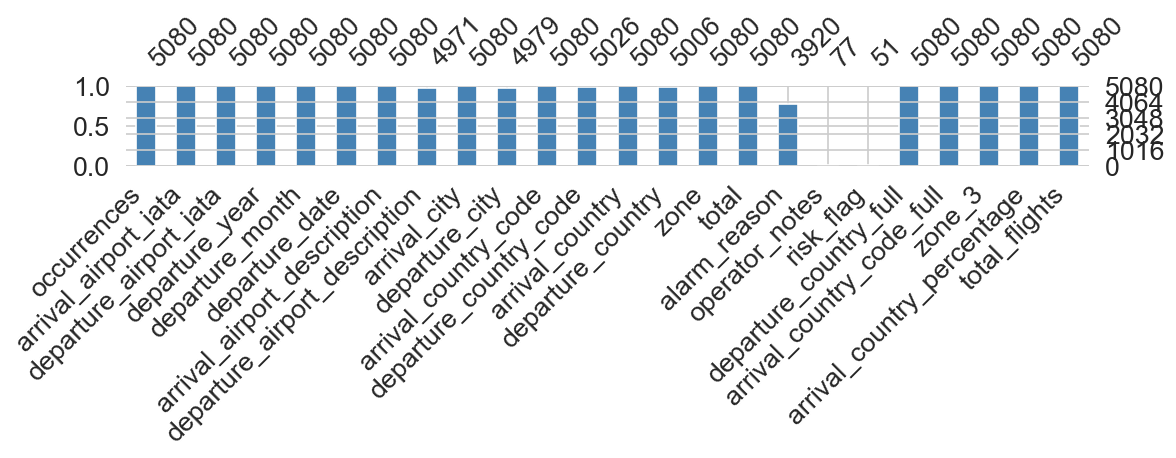

  ▸ Travelers dataset


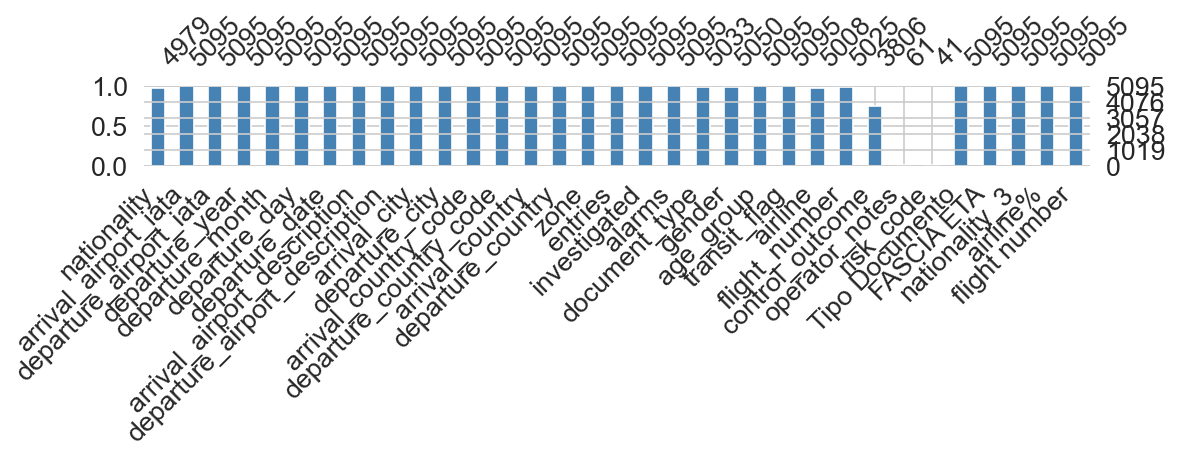

Raw missing-value snapshots saved for later comparison.


In [17]:
print("1.1 — Missingness bar chart (BEFORE cleaning)")
print("  ▸ Alarms dataset")
msno.bar(df_alarms, figsize=(10, 4), color=STEEL)
savefig("missing_bar_alarms_raw")

print("  ▸ Travelers dataset")
msno.bar(df_travelers, figsize=(10, 4), color=STEEL)
savefig("missing_bar_travelers_raw")

# Snapshots for later before/after comparison
raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape
raw_cols_alarms       = list(df_alarms.columns)
raw_cols_travelers    = list(df_travelers.columns)
print("Raw missing-value snapshots saved for later comparison.")

### 1.2 · Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

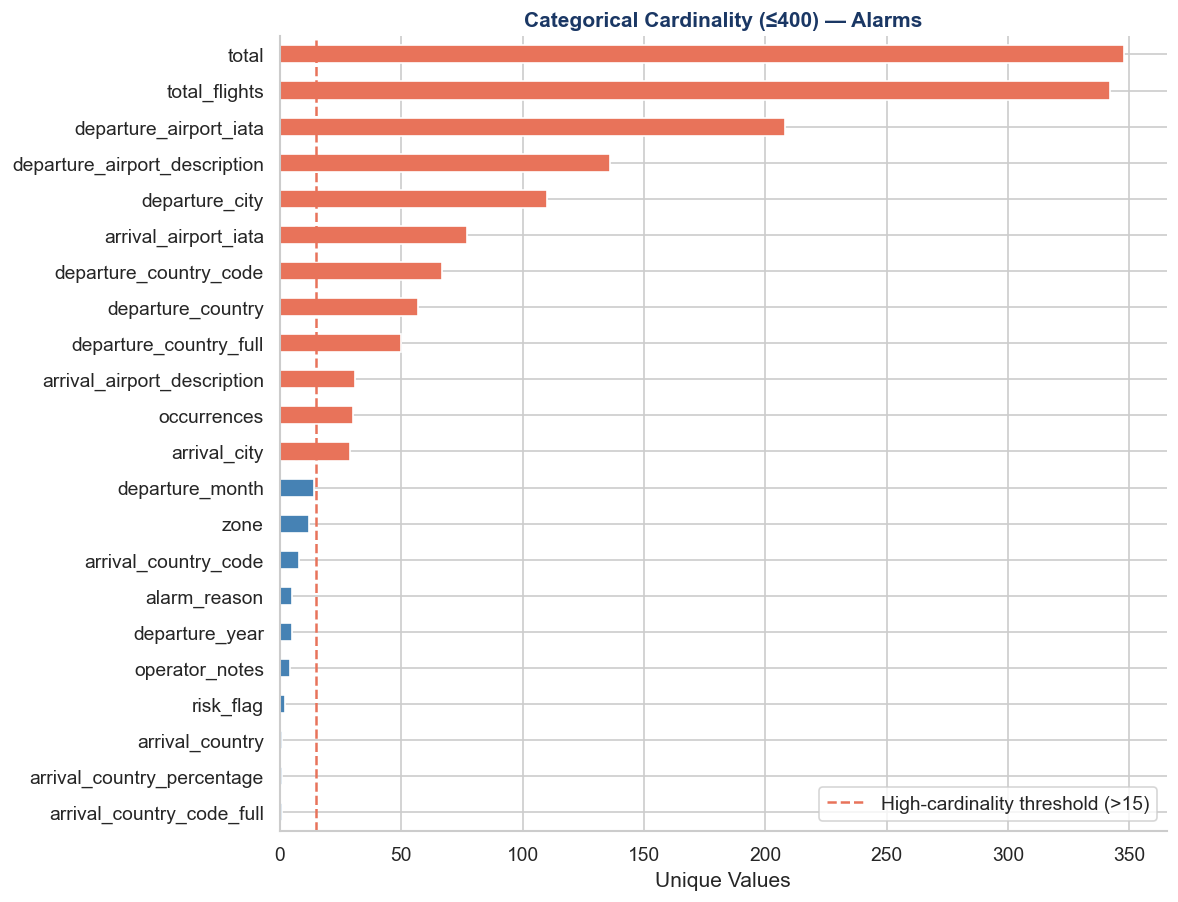

HIGH-CARDINALITY features (excluded from chart):
    ➤ 'departure_date': 3810 unique — needs deep cleaning

  Reviewing unique values (Alarms):
  ➤ 'arrival_country_code_full' (1 values): ['ITA']

  ➤ 'arrival_country_percentage' (1 values): ['Italia']

  ➤ 'arrival_country' (1 values): ['Italia']

  ➤ 'risk_flag' (2 values): ['ALTO', 'MEDIO']

  ➤ 'operator_notes' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  ➤ 'departure_year' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  ➤ 'alarm_reason' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  ➤ 'arrival_country_code' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  ➤ 'zone' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  ➤ 'departure_month' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  ➤ 'arrival_city' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'B

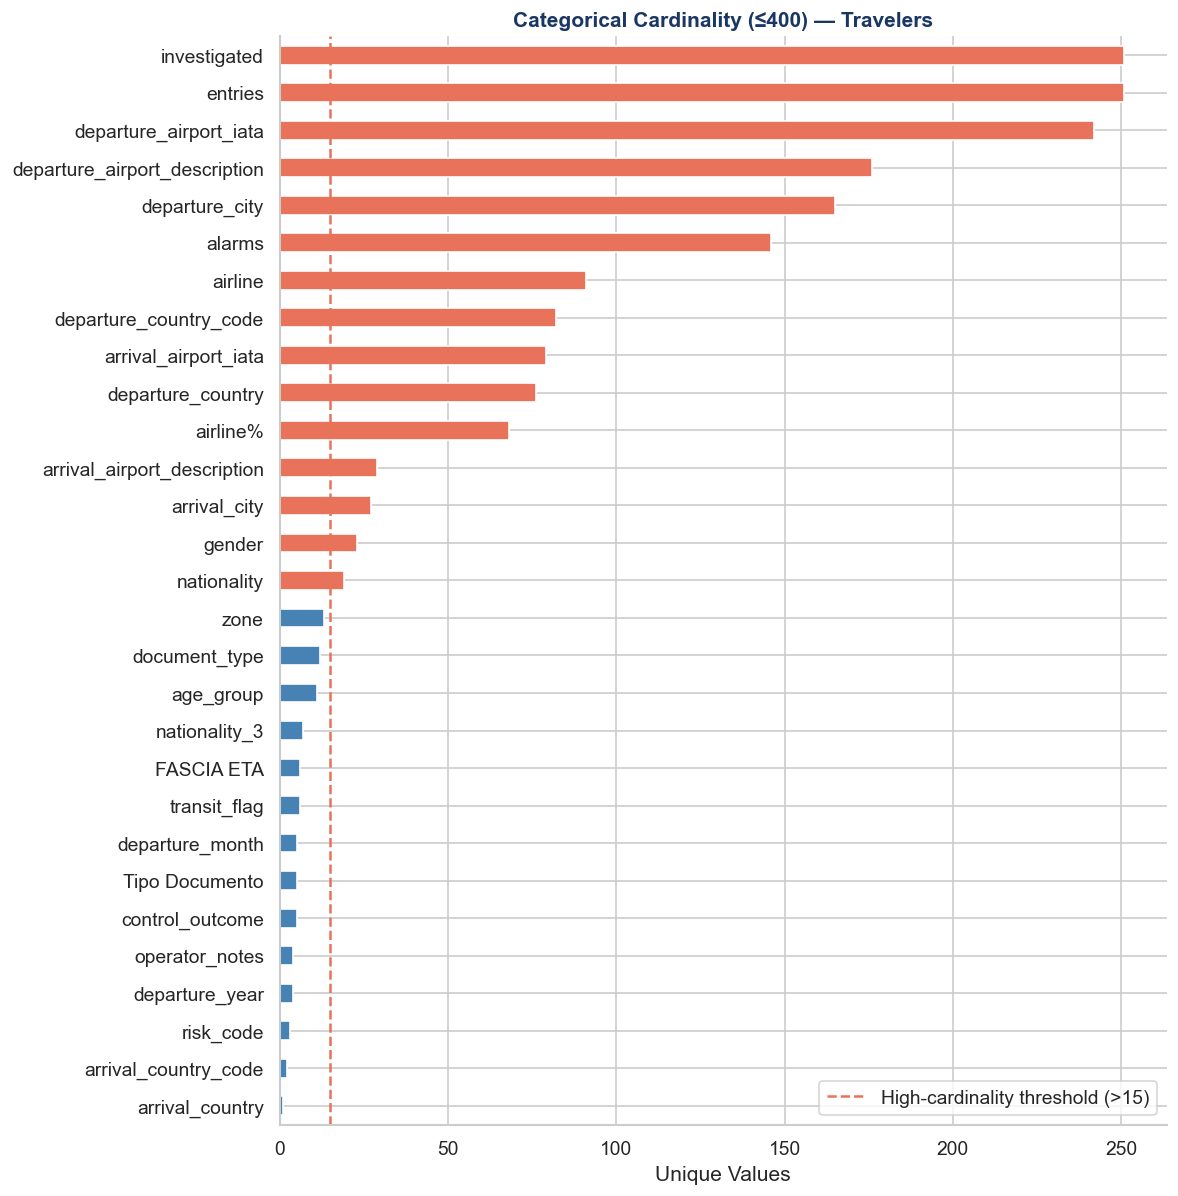

HIGH-CARDINALITY features (excluded from chart):
    ➤ 'flight_number': 701 unique — needs deep cleaning
    ➤ 'flight number': 706 unique — needs deep cleaning
    ➤ 'departure_date': 3977 unique — needs deep cleaning

  Reviewing unique values (Travelers):
  ➤ 'arrival_country' (1 values): ['Italia']

  ➤ 'arrival_country_code' (2 values): ['IT', 'ITA']

  ➤ 'risk_code' (3 values): ['R1', 'R2', 'R3']

  ➤ 'departure_year' (4 values): ['2023', '2024', '24', 'anno 2024']

  ➤ 'operator_notes' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  ➤ 'control_outcome' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  ➤ 'Tipo Documento' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  ➤ 'departure_month' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  ➤ 'transit_flag' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'singola tratta']

  ➤ 'FASCIA ETA'

In [18]:
def inspect_categorical(df, dataset_name):
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical Cardinality (≤400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique Values"); plt.legend(); sns.despine()
        savefig(f"cardinality_{dataset_name.lower().replace(' ', '_')}")

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    ➤ '{col}': {val} unique — needs deep cleaning")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  ➤ '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 1.3 · Redundant-column resolution (Travelers)

The Travelers dataset ships with duplicated columns that encode the same logical field under different formats (e.g. `document_type` vs `document_type2`, `flight_number` vs `flight number`, `nationality` vs `nationality_3`). For each pair we:

1. quantify how many rows conflict (both non-null but different after normalisation);
2. **fill NaNs of the "keep" column with values from the "drop" column** — previously this coalescing step was only *inspected*, never executed;
3. drop the redundant column once merged.

Choice of which column to keep is based on completeness as noted during manual pipeline review.

In [19]:
redundant_pairs = [
    ("document_type",  "document_type2"),
    ("airline",        "airline%"),
    ("flight_number",  "flight number"),
    ("nationality",    "nationality_3"),
    ("age_group",      "age_group2"),
]

def _norm(s): return s.astype(str).str.strip().str.upper()

for keep_col, drop_col in redundant_pairs:
    if keep_col not in df_travelers.columns or drop_col not in df_travelers.columns:
        print(f"  ⚠ Column pair missing: '{keep_col}' / '{drop_col}' — skipped")
        continue
    s_keep, s_drop = df_travelers[keep_col], df_travelers[drop_col]
    mask_conflict = s_keep.notna() & s_drop.notna() & (_norm(s_keep) != _norm(s_drop))
    n_conflicts   = mask_conflict.sum()
    n_filled      = s_keep.isna().sum() - s_keep.fillna(s_drop).isna().sum()
    df_travelers[keep_col] = s_keep.fillna(s_drop)
    print(f"  ➤ '{keep_col}' ← merged from '{drop_col}'  "
          f"| {n_filled} NaNs filled | {n_conflicts} conflicts")
    if n_conflicts > 0:
        display(df_travelers.loc[mask_conflict, [keep_col, drop_col]].head(3))

cols_to_drop = [c for _, c in redundant_pairs if c in df_travelers.columns]
df_travelers.drop(columns=cols_to_drop, inplace=True)
print(f"\n  ✔ Dropped redundant columns: {cols_to_drop}")
print(f"  ✔ Travelers now has {df_travelers.shape[1]} columns (was {raw_shape_travelers[1]}).")

  ⚠ Column pair missing: 'document_type' / 'document_type2' — skipped
  ➤ 'airline' ← merged from 'airline%'  | 87 NaNs filled | 180 conflicts


,airline,airline%
26,//,Turkish Airlines
28,?,Ryanair DAC
51,-,Easyjet


  ➤ 'flight_number' ← merged from 'flight number'  | 70 NaNs filled | 134 conflicts


,flight_number,flight number
45,,AA0198
55,,BA0604
101,n.d.,W43845


  ➤ 'nationality' ← merged from 'nationality_3'  | 116 NaNs filled | 205 conflicts


,nationality,nationality_3
14,//,ALB
39,n.d.,ALB
61,,AFG


  ⚠ Column pair missing: 'age_group' / 'age_group2' — skipped

  ✔ Dropped redundant columns: ['airline%', 'flight number', 'nationality_3']
  ✔ Travelers now has 30 columns (was 33).


### 1.4 · Text standardisation & unknown-value unification (Travelers)

We perform three passes over every text column:

1. `strip + UPPERCASE` to collapse trivial casing/whitespace variants;
2. map all unknown tokens (`ND`, `UNKNOWN`, `N/A`, …) to the canonical `'N.D.'` so that they remain *informative categoricals* rather than fake NaNs;
3. convert *junk* tokens (`-`, `//`, `?`, `XX`, …) into proper `NaN` so that downstream imputation logic can see them.

In [20]:
text_cols = df_travelers.select_dtypes(include=["object"]).columns

for col in text_cols:
    df_travelers[col] = df_travelers[col].astype(str).str.strip().str.upper()

unknown_variants = ["ND", "UNKNOWN", "UNKN", "N/A", "N/C"]
df_travelers[text_cols] = df_travelers[text_cols].replace(unknown_variants, "N.D.")

junk_values = ["-", "//", "?", "???", "XX", "ZZ", "NAN", ""]
df_travelers[text_cols] = df_travelers[text_cols].replace(junk_values, np.nan)

print("  ✔ Text → UPPERCASE, unknown variants → 'N.D.', junk → NaN.")
for col in ["departure_airport_iata", "arrival_airport_iata", "gender"]:
    if col in df_travelers.columns:
        print(f"    '{col}' unique: {sorted(df_travelers[col].dropna().unique())}")

  ✔ Text → UPPERCASE, unknown variants → 'N.D.', junk → NaN.
    'departure_airport_iata' unique: ['ABJ', 'ADB', 'ADD', 'ADL', 'AER', 'AKL', 'ALA', 'ALG', 'AMD', 'AMM', 'ARN', 'ASB', 'ASM', 'ATL', 'AUH', 'AYT', 'BAH', 'BEG', 'BFS', 'BHX', 'BKK', 'BLR', 'BNA', 'BNE', 'BOG', 'BOS', 'BRS', 'BSB', 'BUF', 'CAI', 'CAN', 'CEB', 'CGK', 'CLE', 'CMN', 'CUN', 'CVG', 'DAR', 'DEL', 'DFW', 'DMM', 'DOH', 'DPS', 'DSS', 'DTW', 'DUR', 'DWC', 'DXB', 'EDI', 'ELQ', 'EMA', 'ESB', 'EVN', 'EWR', 'EZE', 'FEZ', 'FIH', 'FLL', 'FRA', 'FRU', 'FUK', 'GIG', 'GLA', 'GRU', 'GYD', 'GZT', 'HAN', 'HGH', 'HKG', 'HKT', 'HND', 'HRG', 'IAD', 'IAH', 'ICN', 'IFN', 'IKA', 'ISB', 'IST', 'JAX', 'JED', 'JFK', 'KBL', 'KCH', 'KIV', 'KUL', 'KUT', 'KWI', 'KZN', 'LAD', 'LAS', 'LAX', 'LCY', 'LGW', 'LHR', 'LOS', 'LPL', 'LRM', 'LTN', 'MAN', 'MBA', 'MCT', 'MED', 'MEL', 'MEX', 'MHD', 'MIA', 'MJI', 'MLE', 'MNL', 'MPM', 'MRU', 'MYR', 'NAV', 'NBO', 'NCL', 'NOS', 'NRT', 'NSI', 'ORD', 'OUA', 'OXB', 'PEK', 'PER', 'PEW', 'PHL', 'PKX', 'POA', 'PRN'

### 1.5 · Numeric & domain-specific standardisation (Travelers)

Numeric columns in Travelers arrive mixed with unit suffixes (`PAX`), Italian decimal commas, and illegal sentinels. We handle them in four sub-steps.

**1.5.a** — Recode Italian 2-digit years and month abbreviations; align country codes (`IT` → `ITA`).  
**1.5.b** — `entries`, `investigated`, `alarms`: comma → dot, strip non-numeric, clip to plausible bounds `[0, 1000]`, cast to pandas nullable `Int64` (you cannot have 1.5 passengers).  
**1.5.c** — `zone`: clean to integer in `[0, 10]`.  
**1.5.d** — `gender`: collapse numeric codes (`1`/`2`), Italian (`MASCHIO`/`FEMMINA`), and English variants to canonical `M/F/X`.

In [21]:
# 1.5a — logical mapping
if "arrival_country_code" in df_travelers.columns:
    df_travelers["arrival_country_code"] = (
        df_travelers["arrival_country_code"].replace({"IT": "ITA"})
    )

if "departure_year" in df_travelers.columns:
    df_travelers["departure_year"] = df_travelers["departure_year"].replace(
        {"24": "2024", "ANNO 2024": "2024", "anno 2024": "2024"})

if "departure_month" in df_travelers.columns:
    df_travelers["departure_month"] = df_travelers["departure_month"].replace(
        {"GEN": "01", "FEB": "02"})

# 1.5b — numeric cleaning
quant_cols = ["entries", "investigated", "alarms"]
for col in quant_cols:
    if col not in df_travelers.columns: continue
    before_dtype, before_nulls = df_travelers[col].dtype, df_travelers[col].isna().sum()
    df_travelers[col] = df_travelers[col].astype(str).str.replace(",", ".")
    df_travelers[col] = df_travelers[col].str.replace(r"[^\d.\-]", "", regex=True)
    df_travelers[col] = pd.to_numeric(df_travelers[col], errors="coerce")
    df_travelers.loc[(df_travelers[col] < 0) | (df_travelers[col] > 1000), col] = np.nan
    df_travelers[col] = df_travelers[col].astype("Int64")
    print(f"    {col}: dtype {before_dtype}→{df_travelers[col].dtype}"
          f"  |  NaN {before_nulls}→{df_travelers[col].isna().sum()}")

# 1.5c — zone
if "zone" in df_travelers.columns:
    df_travelers["zone"] = df_travelers["zone"].astype(str).str.strip()
    df_travelers["zone"] = df_travelers["zone"].replace(["??", "?", "-"], np.nan)
    df_travelers["zone"] = pd.to_numeric(df_travelers["zone"], errors="coerce")
    df_travelers.loc[(df_travelers["zone"] < 0) | (df_travelers["zone"] > 10), "zone"] = np.nan
    df_travelers["zone"] = df_travelers["zone"].astype("Int64")

# 1.5d — gender
if "gender" in df_travelers.columns:
    gender_map = {"1": "M", "MALE": "M", "MASCHIO": "M", "M": "M",
                  "2": "F", "FEMALE": "F", "FEMMINA": "F", "F": "F",
                  "N/B": "X", "X": "X"}
    df_travelers["gender"] = df_travelers["gender"].replace(gender_map)
    print(f"  ✔ gender normalised: {sorted(df_travelers['gender'].dropna().unique())}")

    entries: dtype object→Int64  |  NaN 40→91
    investigated: dtype object→Int64  |  NaN 33→91
    alarms: dtype object→Int64  |  NaN 33→79
  ✔ gender normalised: ['F', 'M', 'N.D.', 'X']


### 1.6 · Date parsing & temporal alignment

The two datasets use *different* date conventions, and the Alarms file in particular mixes at least six formats (`dd/mm/yyyy HH:MM:SS`, `yyyy/mm/dd`, `dd.mm.yyyy`, `MMM dd yyyy` with Italian month abbreviations, `dd-mm-yy`, …). We:

1. print the format distribution *before* cleaning by replacing digits with `N` and letters with `A` (a "pattern fingerprint" technique);
2. rewrite each known pattern to ISO 8601 via regex;
3. parse with `pd.to_datetime(..., errors='coerce')`;
4. print the fingerprint distribution *after* cleaning to verify every row now conforms.

In [22]:
def extract_pattern(val):
    s = str(val)
    s = re.sub(r"\d", "N", s)
    s = re.sub(r"[a-zA-Z]", "A", s)
    return s

print("\n  Date-format patterns BEFORE cleaning:")
trav_before = df_travelers["departure_date"].dropna().map(extract_pattern).value_counts()
alar_before = df_alarms["departure_date"].dropna().map(extract_pattern).value_counts()
print("    Travelers:\n    " + trav_before.to_string().replace("\n", "\n    "))
print("    Alarms:\n    "   + alar_before.to_string().replace("\n", "\n    "))

# Regex normalisation — Alarms
df_alarms["departure_date"] = (df_alarms["departure_date"].astype(str)
    .str.replace(r"(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2}):(\d{2})",
                 r"\3-\2-\1 \4:\5:\6", regex=True))
df_alarms["departure_date"] = (df_alarms["departure_date"].astype(str)
    .str.replace(r"(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})", r"\1 \2", regex=True))
df_alarms["departure_date"] = (df_alarms["departure_date"].astype(str)
    .str.replace(r"(\d{4})/(\d{2})/(\d{2})", r"\1-\2-\3 00:00:00", regex=True))
df_alarms["departure_date"] = (df_alarms["departure_date"].astype(str)
    .str.replace(r"(\d{2})\.(\d{2})\.(\d{4})", r"\3-\2-\1 00:00:00", regex=True))
df_alarms["departure_date"] = pd.to_datetime(
    df_alarms["departure_date"].astype(str)
        .str.extract(r"([A-Za-z]{3} \d{2} \d{4})")[0],
    format="%b %d %Y", errors="coerce"
).dt.strftime("%Y-%m-%d 00:00:00").fillna(df_alarms["departure_date"])
df_alarms["departure_date"] = (df_alarms["departure_date"].astype(str)
    .str.replace(r"^(\d{2})-(\d{2})-(\d{2})$",
                 lambda m: f"20{m.group(3)}-{m.group(2)}-{m.group(1)} 00:00:00",
                 regex=True))

df_alarms["departure_date"]    = pd.to_datetime(df_alarms["departure_date"],    errors="coerce")
df_travelers["departure_date"] = pd.to_datetime(df_travelers["departure_date"], errors="coerce")

print("\n  Date-format patterns AFTER cleaning:")
trav_after = df_travelers["departure_date"].dropna().astype(str).map(extract_pattern).value_counts()
alar_after = df_alarms["departure_date"].dropna().astype(str).map(extract_pattern).value_counts()
print("    Travelers:\n    " + trav_after.to_string().replace("\n", "\n    "))
print("    Alarms:\n    "   + alar_after.to_string().replace("\n", "\n    "))
print(f"\n  Parse failures (NaT): Alarms={df_alarms['departure_date'].isna().sum()} "
      f"| Travelers={df_travelers['departure_date'].isna().sum()}")

# Force numeric types on remaining quantitative columns
for col in ["total", "zone_3", "total_flights", "zone"]:
    if col in df_alarms.columns:
        df_alarms[col] = pd.to_numeric(df_alarms[col], errors="coerce")
for col in ["entries", "investigated", "alarms"]:
    if col in df_travelers.columns:
        df_travelers[col] = pd.to_numeric(df_travelers[col], errors="coerce")


  Date-format patterns BEFORE cleaning:
    Travelers:
    departure_date
    AAAA-AA-AA AA:AA:AA    4689
    AAA AA AAAA              81
    AA-AA-AA                 70
    AAAA-AA-AAAAA:AA:AA      68
    AAAA/AA/AA               66
    AA/AA/AAAA AA:AA:AA      66
    AA.AA.AAAA               55
    Alarms:
    departure_date
    AAAA-AA-AA AA:AA:AA    4675
    AAAA/AA/AA               76
    AA-AA-AA                 76
    AAA AA AAAA              68
    AA.AA.AAAA               62
    AAAA-AA-AAAAA:AA:AA      62
    AA/AA/AAAA AA:AA:AA      61

  Date-format patterns AFTER cleaning:
    Travelers:
    departure_date
    AAAA-AA-AA AA:AA:AA    4689
    Alarms:
    departure_date
    AAAA-AA-AA AA:AA:AA    4986

  Parse failures (NaT): Alarms=94 | Travelers=406


### 1.7 · Alarms dataset — full cleaning pipeline

We apply nine sub-steps specific to the Alarms file:

- **1.7.a** uppercase all column names (switch of convention for this dataset only);
- **1.7.b** strip + case-normalise key text columns (upper for ISO codes, Title Case for city/country names);
- **1.7.c** clean month/year columns, then drop them — `departure_date` is now authoritative;
- **1.7.d** enrich country information (fix Italian rows, merge `DEPARTURE_COUNTRY_FULL` into `DEPARTURE_COUNTRY`);
- **1.7.e** standardise `RISK_FLAG` to English (`ALTO→HIGH`, `MEDIO→MEDIUM`, NaN → `LOW`);
- **1.7.f** replace null `OPERATOR_NOTES`/`ALARM_REASON` with a descriptive placeholder (preserves observation count);
- **1.7.g** derive ISO alpha-3 `DEPARTURE_COUNTRY_CODE` via `pycountry`;
- **1.7.h** clean city/airport descriptions and back-fill them from `iata_mapping` where possible;
- **1.7.i** resolve redundant numeric columns `TOTAL` vs `TOTAL_FLIGHTS`, and `ZONE` vs `ZONE_3`.

In [23]:
# 1.7a — uppercase columns
df_alarms.columns = df_alarms.columns.str.upper()
missing_tokens = ["", "-", "//", "?", "n.d.", "nd", "n/a", "null",
                  "unknown", "N.D.", "ND", "UNKNOWN", "XX", "ZZ", "00"]

# 1.7b — case-normalise key text columns
upper_cols = ["ARRIVAL_AIRPORT_IATA", "DEPARTURE_COUNTRY_CODE",
              "DEPARTURE_AIRPORT_IATA", "DEPARTURE_COUNTRY",
              "ARRIVAL_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE_FULL"]
for col in upper_cols:
    if col in df_alarms.columns:
        df_alarms[col] = df_alarms[col].astype(str).str.strip().str.upper()

title_cols = ["ARRIVAL_AIRPORT_DESCRIPTION", "DEPARTURE_AIRPORT_DESCRIPTION",
              "ARRIVAL_CITY", "DEPARTURE_CITY", "DEPARTURE_COUNTRY",
              "ARRIVAL_COUNTRY", "ARRIVAL_COUNTRY_PERCENTAGE", "DEPARTURE_COUNTRY_FULL"]
for col in title_cols:
    if col in df_alarms.columns:
        df_alarms[col] = df_alarms[col].astype(str).str.strip().str.title()

# 1.7c — clean then drop redundant month/year
if "DEPARTURE_MONTH" in df_alarms.columns:
    df_alarms["DEPARTURE_MONTH"] = df_alarms["DEPARTURE_MONTH"].replace({
        "GEN":"01","FEB":"02","MAR":"03","APR":"04","MAG":"05","GIU":"06",
        "LUG":"07","AGO":"08","SET":"09","OTT":"10","NOV":"11","DIC":"12"})
if "DEPARTURE_YEAR" in df_alarms.columns:
    df_alarms["DEPARTURE_YEAR"] = df_alarms["DEPARTURE_YEAR"].replace(
        {"2024.":"2024","24":"2024","anno 2024":"2024"})
for col in ["DEPARTURE_YEAR", "DEPARTURE_MONTH"]:
    if col in df_alarms.columns:
        df_alarms.drop(columns=[col], inplace=True)
        print(f"  ✔ Dropped '{col}' (redundant — extracted from DEPARTURE_DATE)")

# 1.7d — country enrichment
if "ARRIVAL_COUNTRY" in df_alarms.columns:
    mask_it = df_alarms["ARRIVAL_COUNTRY"].str.lower().str.strip() == "italia"
    df_alarms.loc[mask_it, "ARRIVAL_COUNTRY_CODE"] = "ITA"
    print(f"  ✔ Fixed ARRIVAL_COUNTRY_CODE for {mask_it.sum()} Italian rows")

if {"DEPARTURE_COUNTRY_FULL", "DEPARTURE_COUNTRY"}.issubset(df_alarms.columns):
    before = df_alarms["DEPARTURE_COUNTRY"].isna().sum()
    df_alarms["DEPARTURE_COUNTRY"] = (
        df_alarms["DEPARTURE_COUNTRY_FULL"].combine_first(df_alarms["DEPARTURE_COUNTRY"]))
    print(f"  ✔ DEPARTURE_COUNTRY enriched: NaN {before}→{df_alarms['DEPARTURE_COUNTRY'].isna().sum()}")

# 1.7e — risk flag
if "RISK_FLAG" in df_alarms.columns:
    df_alarms["RISK_FLAG"] = (df_alarms["RISK_FLAG"].fillna("LOW")
                              .str.upper().replace({"ALTO":"HIGH","MEDIO":"MEDIUM"}))
    print(f"  ✔ RISK_FLAG: {sorted(df_alarms['RISK_FLAG'].dropna().unique())}")

# 1.7f — placeholder for free text
for col in ["OPERATOR_NOTES", "ALARM_REASON"]:
    if col in df_alarms.columns:
        n = df_alarms[col].isna().sum()
        df_alarms[col] = df_alarms[col].fillna("No information provided")
        print(f"  ✔ {col}: filled {n} NaNs with placeholder")

# 1.7g — ISO alpha-3 via pycountry
def get_alpha3(country_it):
    if pd.isna(country_it): return np.nan
    country_it = str(country_it).strip()
    if country_it == "Cossovo": return "RKS"
    country_en = it_to_en.get(country_it)
    if not country_en: return np.nan
    try:    return pycountry.countries.lookup(country_en).alpha_3
    except LookupError: return np.nan

if "DEPARTURE_COUNTRY" in df_alarms.columns:
    before = df_alarms.get("DEPARTURE_COUNTRY_CODE", pd.Series(dtype="object")).isna().sum()
    df_alarms["DEPARTURE_COUNTRY_CODE"] = df_alarms["DEPARTURE_COUNTRY"].apply(get_alpha3)
    print(f"  ✔ DEPARTURE_COUNTRY_CODE via pycountry: NaN {before}→"
          f"{df_alarms['DEPARTURE_COUNTRY_CODE'].isna().sum()}")

# 1.7h — city/airport cleanup + IATA back-fill
def clean_text(x):
    if pd.isna(x): return np.nan
    return " ".join(str(x).strip().split()).title()

if "DEPARTURE_CITY" in df_alarms.columns:
    df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].replace(city_mapping)
    for col in ["DEPARTURE_CITY", "DEPARTURE_AIRPORT_DESCRIPTION"]:
        if col in df_alarms.columns:
            df_alarms[col] = df_alarms[col].replace(missing_tokens, np.nan)
    df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].apply(clean_text)
if "DEPARTURE_AIRPORT_DESCRIPTION" in df_alarms.columns:
    df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"] = df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].apply(
        lambda x: clean_text(x) if not pd.isna(x) else np.nan)

if "DEPARTURE_AIRPORT_IATA" in df_alarms.columns:
    mapped_city    = df_alarms["DEPARTURE_AIRPORT_IATA"].map(
        lambda x: iata_mapping.get(x, {}).get("city", np.nan)    if pd.notna(x) else np.nan)
    mapped_airport = df_alarms["DEPARTURE_AIRPORT_IATA"].map(
        lambda x: iata_mapping.get(x, {}).get("airport", np.nan) if pd.notna(x) else np.nan)
    if "DEPARTURE_CITY" in df_alarms.columns:
        n = df_alarms["DEPARTURE_CITY"].isna().sum()
        df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].fillna(mapped_city)
        print(f"  ✔ DEPARTURE_CITY back-filled {n - df_alarms['DEPARTURE_CITY'].isna().sum()} via IATA")
    if "DEPARTURE_AIRPORT_DESCRIPTION" in df_alarms.columns:
        n = df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].isna().sum()
        df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"] = df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].fillna(mapped_airport)
        print(f"  ✔ DEPARTURE_AIRPORT_DESCRIPTION back-filled "
              f"{n - df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].isna().sum()} via IATA")

# 1.7i — redundant numeric columns
if {"TOTAL", "TOTAL_FLIGHTS"}.issubset(df_alarms.columns):
    diff = (df_alarms["TOTAL_FLIGHTS"] != df_alarms["TOTAL"]).sum()
    print(f"    TOTAL vs TOTAL_FLIGHTS: {diff} rows differ")
    df_alarms["TOTAL_FLIGHTS"] = df_alarms["TOTAL_FLIGHTS"].fillna(df_alarms["TOTAL"])
    df_alarms.drop(columns=["TOTAL"], inplace=True)
    print("    ✔ Merged TOTAL → TOTAL_FLIGHTS, dropped TOTAL")
if {"ZONE", "ZONE_3"}.issubset(df_alarms.columns):
    diff = (df_alarms["ZONE"] != df_alarms["ZONE_3"]).sum()
    print(f"    ZONE vs ZONE_3: {diff} rows differ")
    df_alarms["ZONE_3"] = df_alarms["ZONE_3"].fillna(df_alarms["ZONE"])
    df_alarms.drop(columns=["ZONE"], inplace=True)
    print("    ✔ Merged ZONE → ZONE_3, dropped ZONE")

  ✔ Dropped 'DEPARTURE_YEAR' (redundant — extracted from DEPARTURE_DATE)
  ✔ Dropped 'DEPARTURE_MONTH' (redundant — extracted from DEPARTURE_DATE)
  ✔ Fixed ARRIVAL_COUNTRY_CODE for 5080 Italian rows
  ✔ DEPARTURE_COUNTRY enriched: NaN 0→0
  ✔ RISK_FLAG: ['HIGH', 'LOW', 'MEDIUM']
  ✔ OPERATOR_NOTES: filled 5003 NaNs with placeholder
  ✔ ALARM_REASON: filled 1160 NaNs with placeholder
  ✔ DEPARTURE_COUNTRY_CODE via pycountry: NaN 0→2838
  ✔ DEPARTURE_CITY back-filled 111 via IATA
  ✔ DEPARTURE_AIRPORT_DESCRIPTION back-filled 151 via IATA
    TOTAL vs TOTAL_FLIGHTS: 201 rows differ
    ✔ Merged TOTAL → TOTAL_FLIGHTS, dropped TOTAL
    ZONE vs ZONE_3: 10 rows differ
    ✔ Merged ZONE → ZONE_3, dropped ZONE


### 1.8 · Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after §1.3 – §1.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


  ALARMS  (shape: (5080, 24) → (5080, 20))


,Missing BEFORE,Missing AFTER
Column,,
ALARM_REASON,—,0
ARRIVAL_AIRPORT_DESCRIPTION,—,0
ARRIVAL_AIRPORT_IATA,—,0
ARRIVAL_CITY,—,0
ARRIVAL_COUNTRY,—,0
ARRIVAL_COUNTRY_CODE,—,0
ARRIVAL_COUNTRY_CODE_FULL,—,0
ARRIVAL_COUNTRY_PERCENTAGE,—,0
DEPARTURE_AIRPORT_DESCRIPTION,—,1



  TRAVELERS  (shape: (5095, 33) → (5095, 30))


,Missing BEFORE,Missing AFTER
Column,,
airline,87,105
airline%,0,dropped
alarms,0,79
departure_date,0,406
document_type,62,140
entries,0,91
flight number,0,dropped
flight_number,70,71
gender,45,110



  Missingness bar chart (AFTER cleaning)
  ▸ Alarms


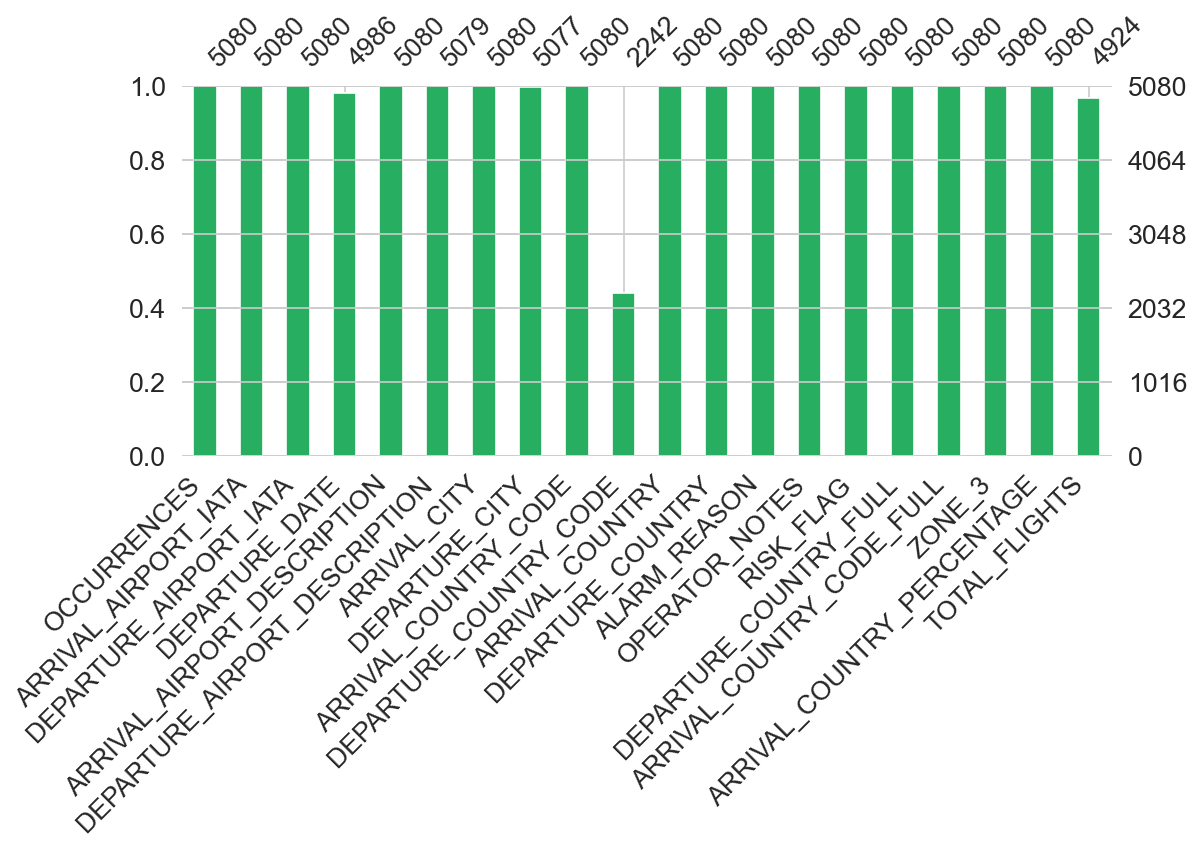

  ▸ Travelers


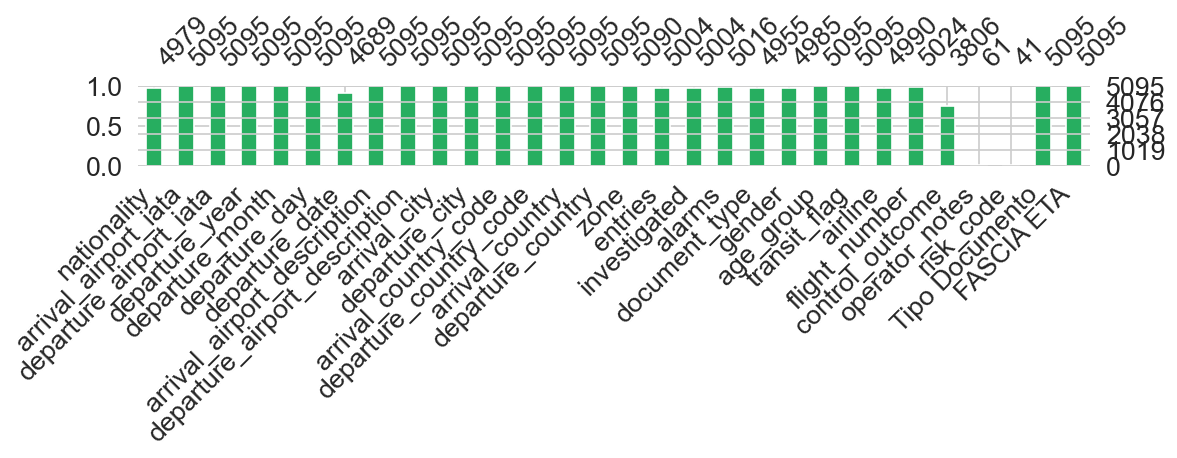

In [24]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    now = df_now.isnull().sum()
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n  {dataset_name}  (shape: {raw_shape} → {df_now.shape})")
    display(report[report["Missing BEFORE"] != report["Missing AFTER"]])

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

print("\n  Missingness bar chart (AFTER cleaning)")
print("  ▸ Alarms");    msno.bar(df_alarms,    figsize=(10, 4), color=GREEN); savefig("missing_bar_alarms_clean")
print("  ▸ Travelers"); msno.bar(df_travelers, figsize=(10, 4), color=GREEN); savefig("missing_bar_travelers_clean")

### 1.9 · Final schema verification and export of cleaned data

We print the final shape, columns and dtype counts for both datasets — the schema contract that the feature-engineering block will depend on.

> **#edits** — we also persist the two cleaned DataFrames to `io/ALARMS_CLEAN.csv` and `io/TRAVELERS_CLEAN.csv`. In the original scripts this step was missing, forcing the Feature-Engineering notebook to load non-existent files via hard-coded Windows paths. With this export the pipeline is reproducible on any machine.

In [25]:
print(f"\n  ALARMS    — {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} cols")
print(f"  Columns: {list(df_alarms.columns)}")
print(f"  Dtypes:\n{df_alarms.dtypes.value_counts().to_string()}\n")

print(f"  TRAVELERS — {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} cols")
print(f"  Columns: {list(df_travelers.columns)}")
print(f"  Dtypes:\n{df_travelers.dtypes.value_counts().to_string()}")

# edits: persist cleaned datasets so the FE block is reproducible
df_alarms.to_csv(ALARMS_CLEAN_PATH,       index=False)
df_travelers.to_csv(TRAVELERS_CLEAN_PATH, index=False)
print(f"\n  ✔ Saved: {ALARMS_CLEAN_PATH.name}")
print(f"  ✔ Saved: {TRAVELERS_CLEAN_PATH.name}")


  ALARMS    — 5,080 rows × 20 cols
  Columns: ['OCCURRENCES', 'ARRIVAL_AIRPORT_IATA', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_DATE', 'ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'ARRIVAL_COUNTRY_CODE', 'DEPARTURE_COUNTRY_CODE', 'ARRIVAL_COUNTRY', 'DEPARTURE_COUNTRY', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'DEPARTURE_COUNTRY_FULL', 'ARRIVAL_COUNTRY_CODE_FULL', 'ZONE_3', 'ARRIVAL_COUNTRY_PERCENTAGE', 'TOTAL_FLIGHTS']
  Dtypes:
object            17
datetime64[ns]     1
int64              1
float64            1

  TRAVELERS — 5,095 rows × 30 cols
  Columns: ['nationality', 'arrival_airport_iata', 'departure_airport_iata', 'departure_year', 'departure_month', 'departure_day', 'departure_date', 'arrival_airport_description', 'departure_airport_description', 'arrival_city', 'departure_city', 'arrival_country_code', 'departure_country_code', 'arrival_country', 'departure_country', 'zone', 'entries', 'investigated', 'alarms', 'document_

## §2 · Univariate Analysis

### 2.1 · Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.


  Descriptive statistics — Alarms:


,count,mean,std,min,25%,50%,75%,max
ZONE_3,5080.00,4.16,2.16,1.00,2.00,4.00,5.00,9.00
TOTAL_FLIGHTS,4924.00,40.81,75.31,0.00,1.00,2.00,28.00,544.00


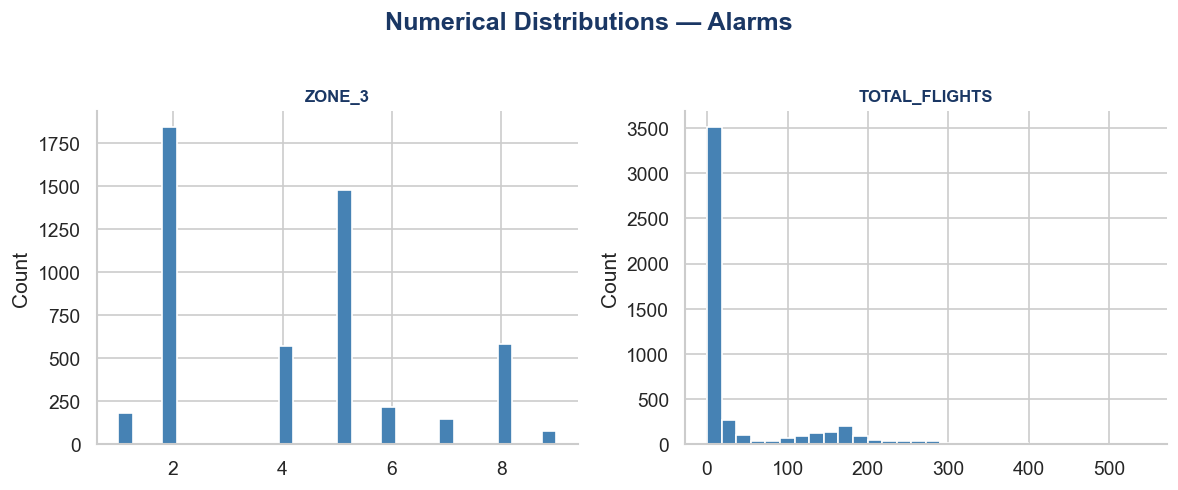


  Descriptive statistics — Travelers:


,count,mean,std,min,25%,50%,75%,max
departure_day,5095.00,15.09,8.63,1.00,8.00,15.00,23.00,31.00
zone,5090.00,4.43,2.48,0.00,2.00,4.00,7.00,10.00
entries,5004.00,36.52,47.44,0.00,1.00,3.00,76.00,186.00
investigated,5004.00,35.60,47.31,0.00,1.00,2.00,75.00,186.00
alarms,5016.00,6.47,13.54,0.00,0.00,1.00,10.00,168.00


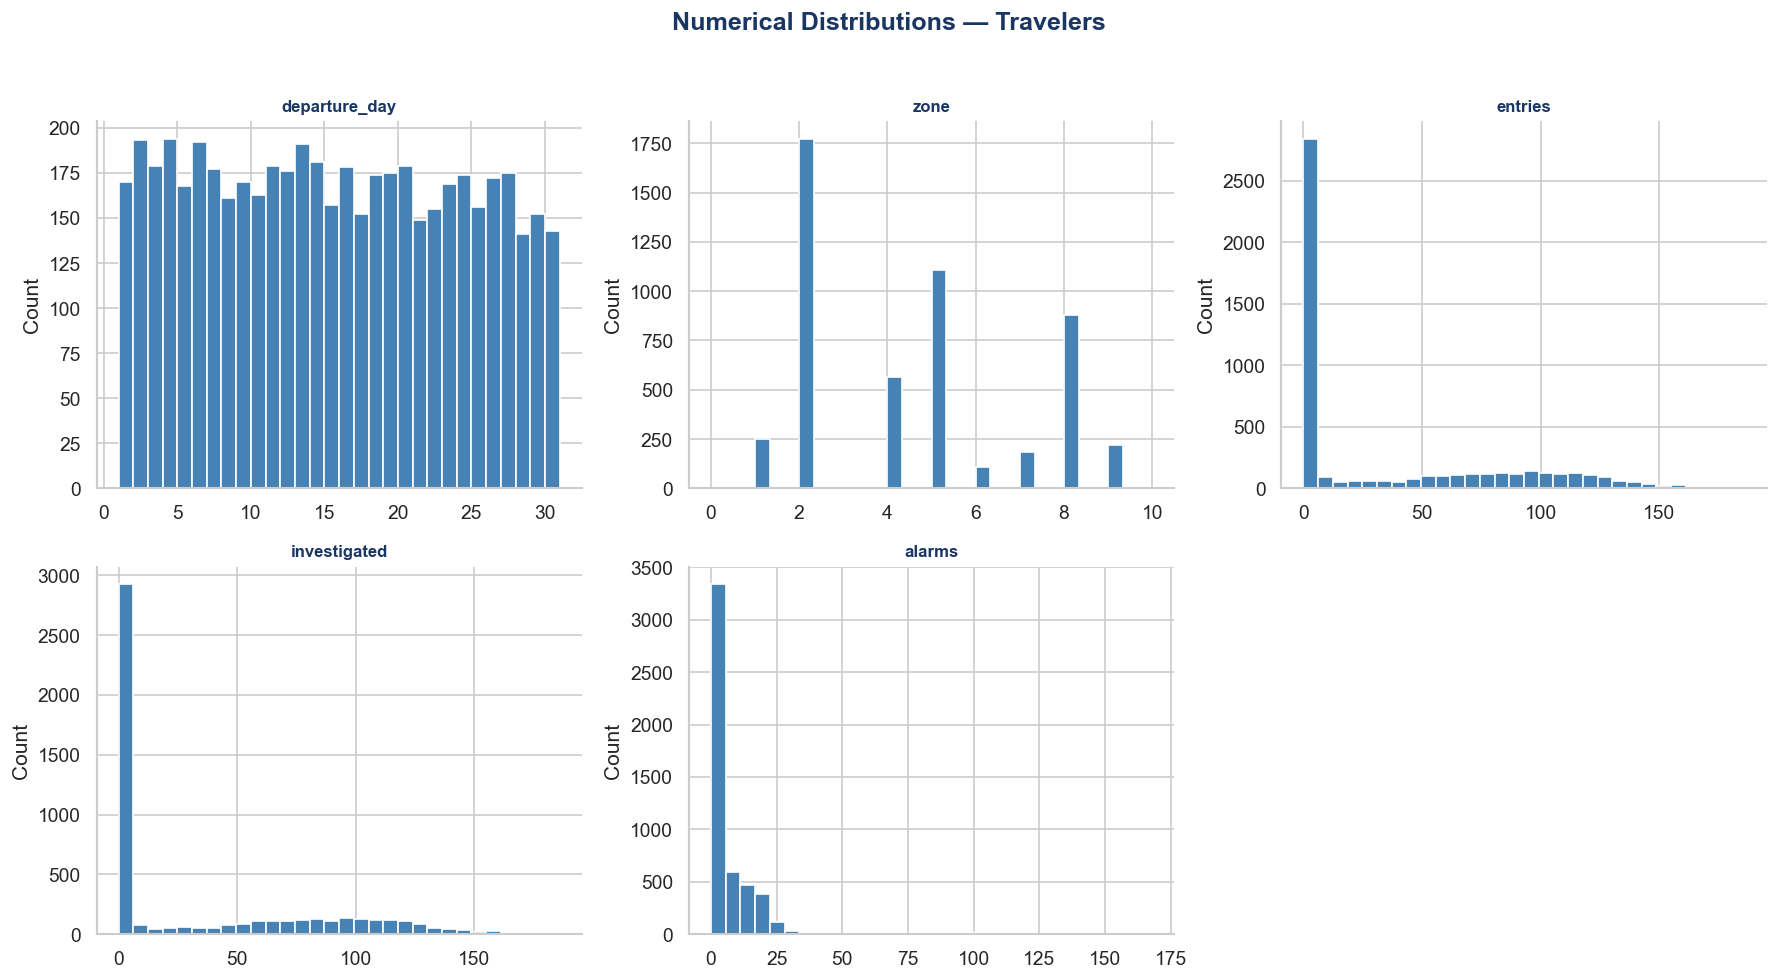

In [26]:
def plot_numeric_distributions(df, dataset_name):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        print(f"  No numeric columns in {dataset_name}."); return
    print(f"\n  Descriptive statistics — {dataset_name}:")
    display(df[num_cols].describe().T)
    n = len(num_cols); ncols = min(3, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        ax = axes[i]
        df[col].dropna().hist(bins=30, ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(col, fontsize=10, color=NAVY, fontweight="bold")
        ax.set_ylabel("Count"); sns.despine(ax=ax)
    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f"Numerical Distributions — {dataset_name}",
                 fontweight="bold", color=NAVY, y=1.02)
    savefig(f"num_dist_{dataset_name.lower()}")

plot_numeric_distributions(df_alarms,    "Alarms")
plot_numeric_distributions(df_travelers, "Travelers")

### 2.2 · Categorical frequency analysis

Bar charts of the top-10 values for the business-relevant categoricals. For Alarms these are `ALARM_REASON`, `RISK_FLAG`, `ARRIVAL_COUNTRY_CODE`; for Travelers they are `gender`, `document_type`, `transit_flag`, `age_group`, `control_outcome`. We use `top_n=10` to avoid drawing uninformative long tails.

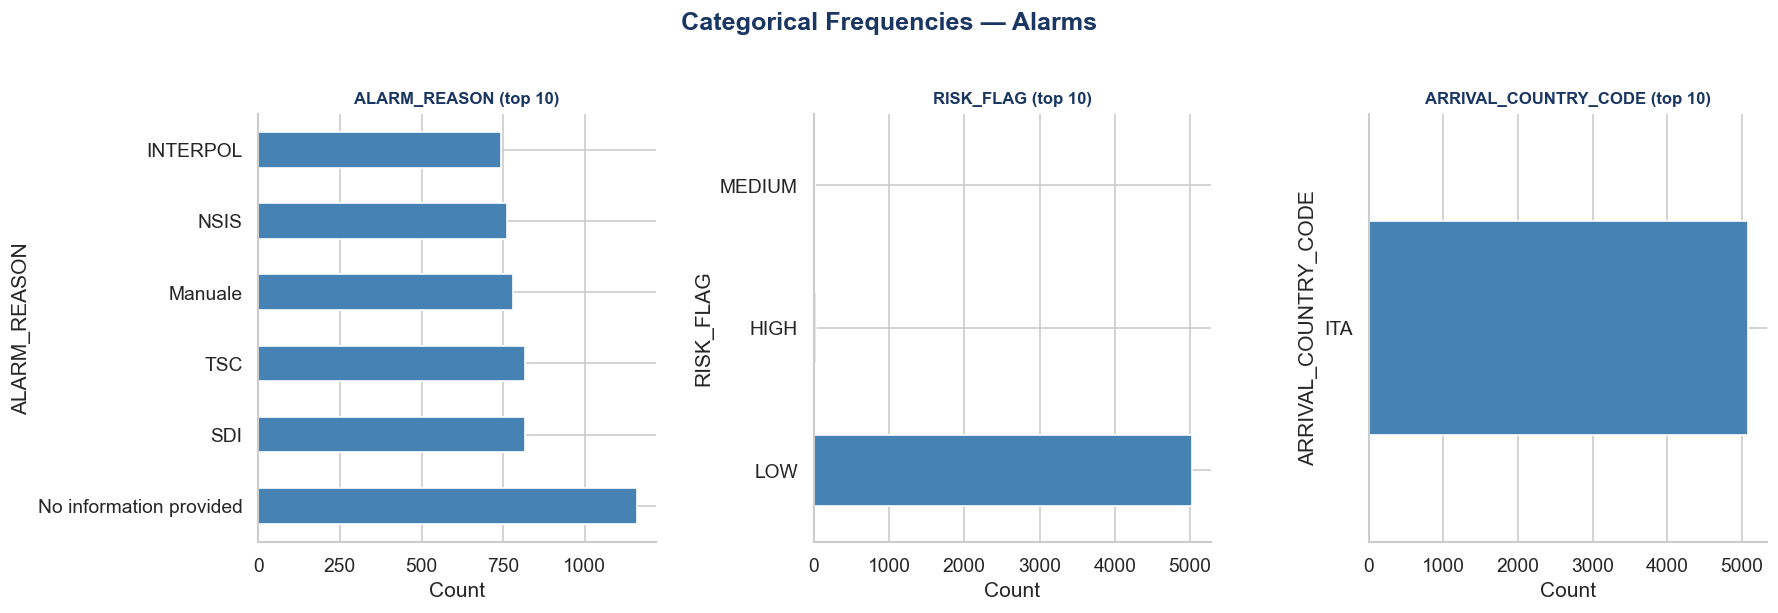

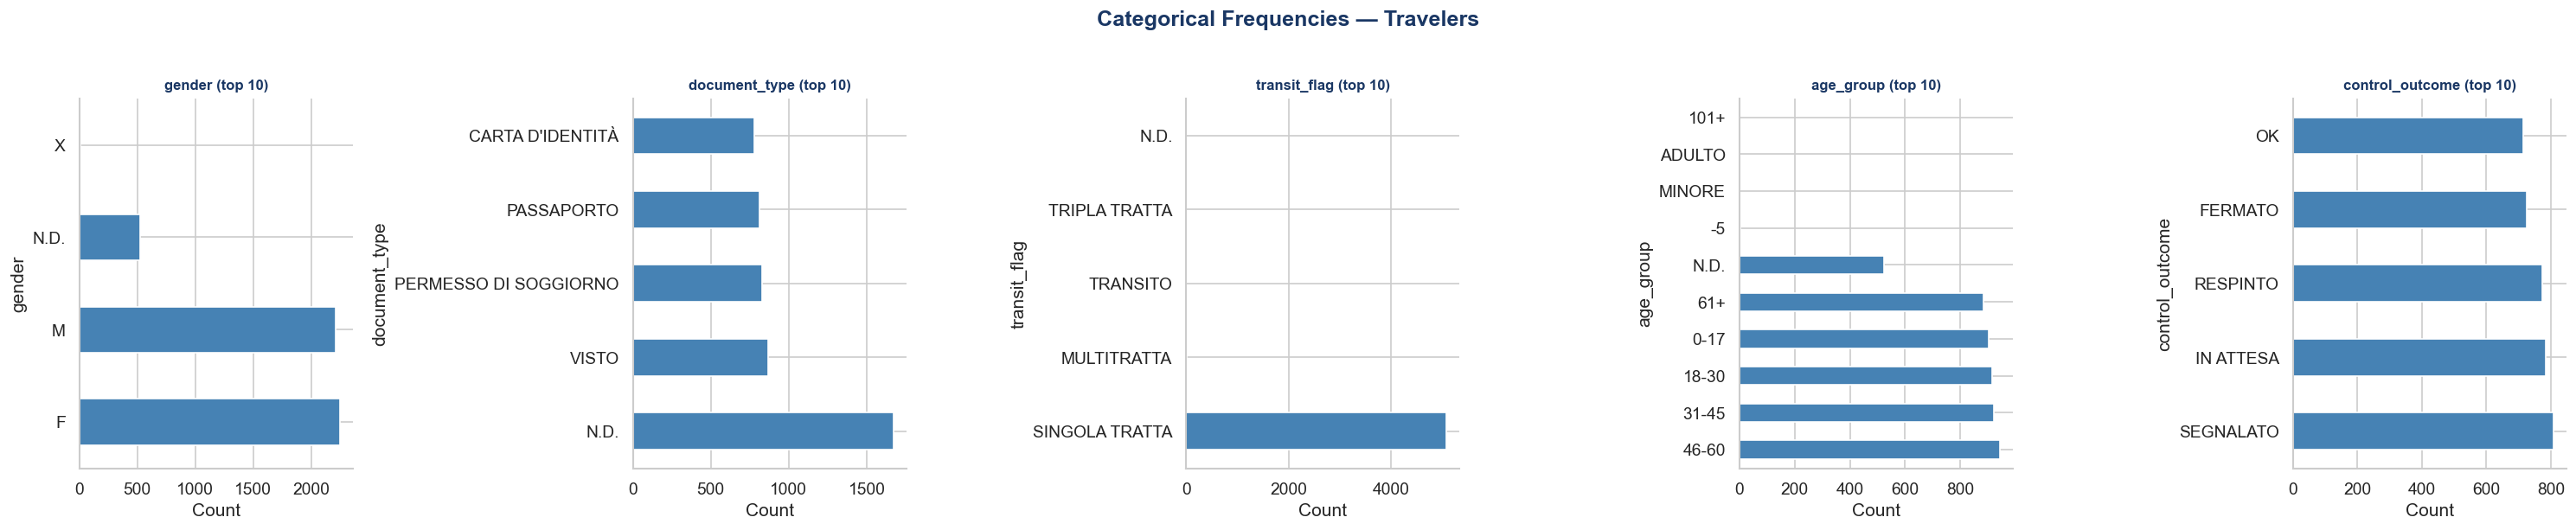

In [27]:
def plot_categorical_freq(df, cols, dataset_name, top_n=10):
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        df[col].value_counts().head(top_n).plot(kind="barh", ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(f"{col} (top {top_n})", fontsize=10, fontweight="bold", color=NAVY)
        ax.set_xlabel("Count"); sns.despine(ax=ax)
    plt.suptitle(f"Categorical Frequencies — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    savefig(f"cat_freq_{dataset_name.lower()}")

plot_categorical_freq(df_alarms,    ["ALARM_REASON", "RISK_FLAG", "ARRIVAL_COUNTRY_CODE"], "Alarms")
plot_categorical_freq(df_travelers, ["gender", "document_type", "transit_flag",
                                     "age_group", "control_outcome"], "Travelers")

### 2.3 · Temporal distribution

We aggregate records at the *month* granularity and plot them as bar charts. The shape of these two time-series tells us (a) whether the coverage period of the two datasets aligns and (b) whether there are any obvious reporting gaps that could bias time-series feature engineering later on.

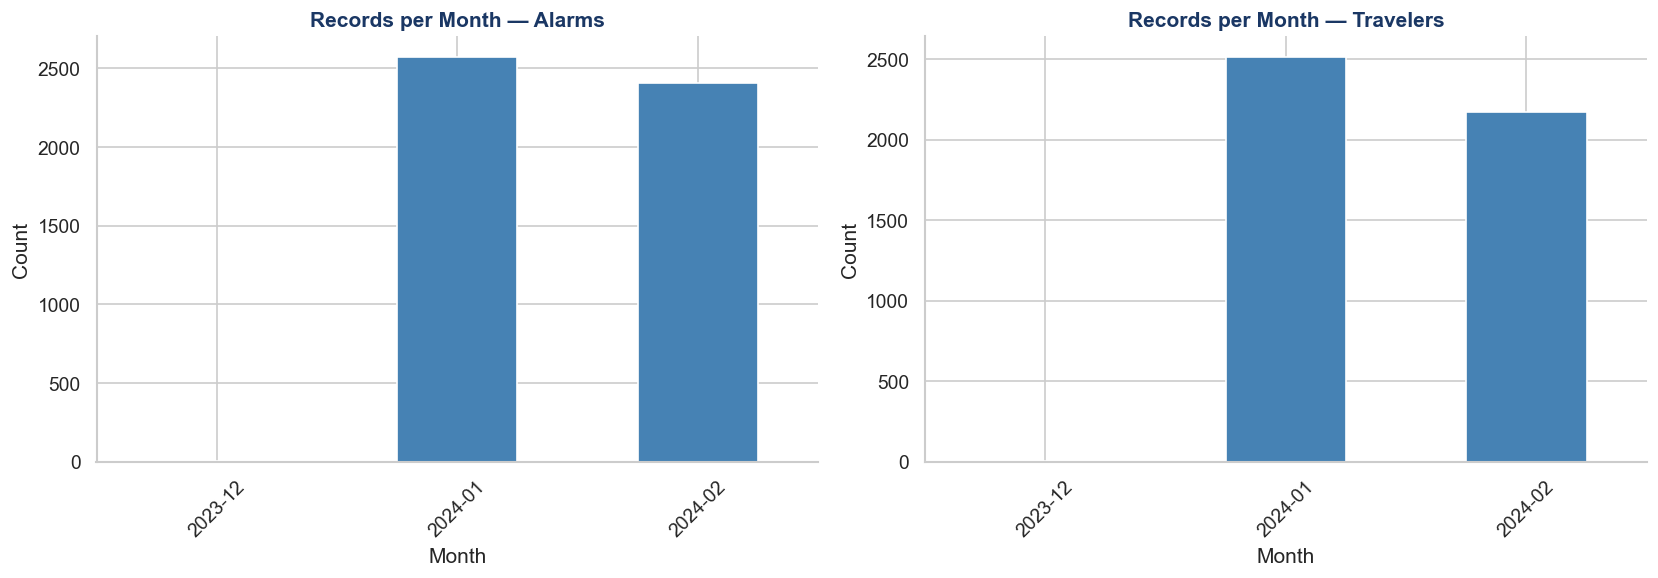

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_tmp, name) in zip(axes, [(df_alarms, "Alarms"), (df_travelers, "Travelers")]):
    date_col = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_tmp.columns else "departure_date"
    if date_col not in df_tmp.columns: continue
    monthly = df_tmp[date_col].dropna().dt.to_period("M").value_counts().sort_index()
    monthly.plot(kind="bar", ax=ax, color=STEEL, edgecolor="white")
    ax.set_title(f"Records per Month — {name}", fontweight="bold", color=NAVY)
    ax.set_xlabel("Month"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45); sns.despine(ax=ax)
savefig("temporal_distribution")

## §3 · Bivariate Analysis

### 3.1 · Entries vs Alarms

The Pearson correlation between passenger `entries` and `alarms` quantifies whether alarm volume simply tracks traffic (a high correlation would mean "bigger airports trigger more alarms just because they have more flow") or whether some routes/days show *excess* alarms given traffic. The latter is exactly the signal we will want to isolate during anomaly detection.

  Pearson r(entries, alarms) = 0.580


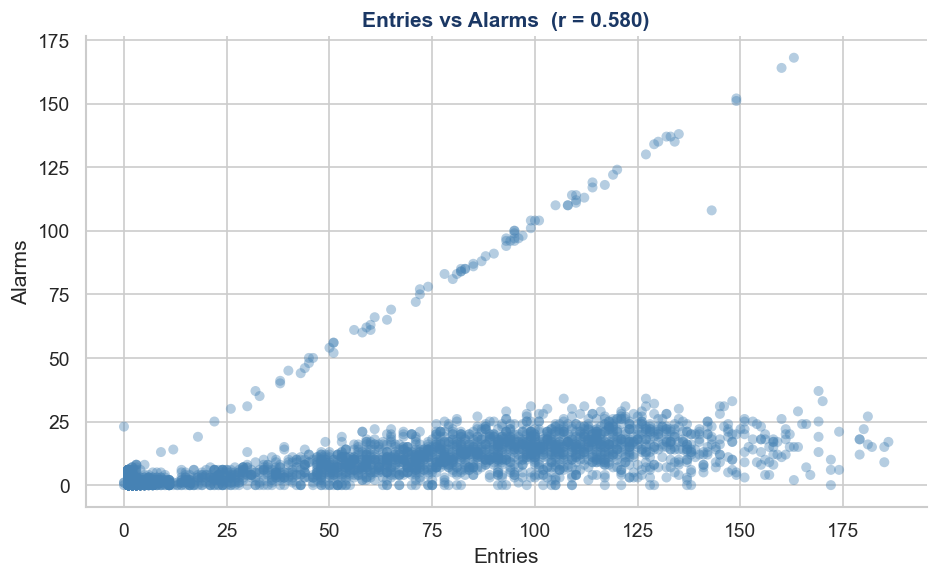

In [29]:
if {"entries", "alarms"}.issubset(df_travelers.columns):
    corr = df_travelers[["entries", "alarms"]].corr().iloc[0, 1]
    print(f"  Pearson r(entries, alarms) = {corr:.3f}")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_travelers, x="entries", y="alarms", alpha=0.4, color=STEEL, edgecolor="none")
    plt.title(f"Entries vs Alarms  (r = {corr:.3f})", fontweight="bold", color=NAVY)
    plt.xlabel("Entries"); plt.ylabel("Alarms"); sns.despine()
    savefig("scatter_entries_alarms")
else:
    print("'entries' or 'alarms' column not found — skipping.")

### 3.2 · Alarm Reason × Zone heatmap

A crosstab of `ALARM_REASON` against `ZONE_3` tells us which types of alarms concentrate in which geographic risk zones. Reading the heatmap row-wise highlights alarm categories that cluster in a single zone (narrow operational footprint); column-wise, it shows zones that receive a disproportionate share of a particular alarm type — both patterns are candidate priors for the anomaly detector.

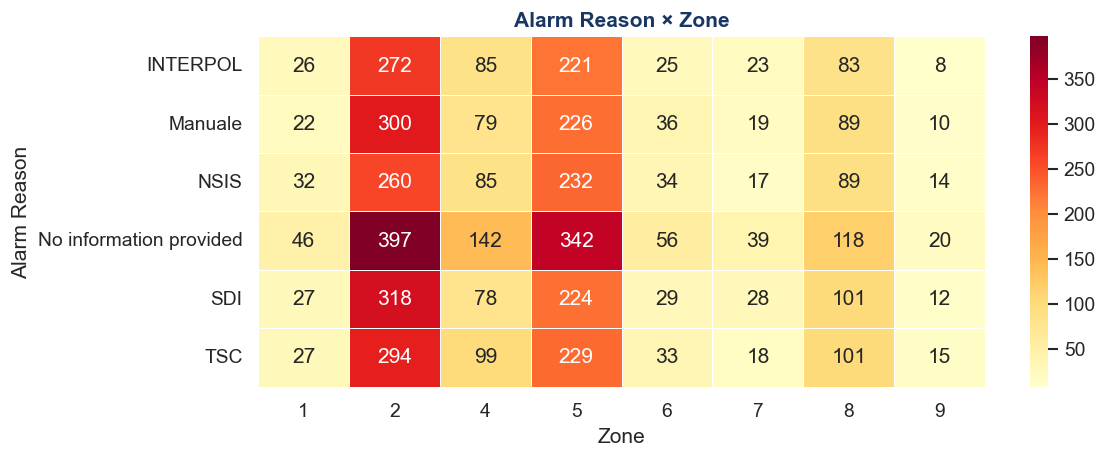

In [30]:
zone_col   = "ZONE_3" if "ZONE_3" in df_alarms.columns else "ZONE"
reason_col = "ALARM_REASON" if "ALARM_REASON" in df_alarms.columns else None

if reason_col and zone_col in df_alarms.columns:
    ct = pd.crosstab(df_alarms[reason_col], df_alarms[zone_col])
    plt.figure(figsize=(10, max(4, len(ct) * 0.5)))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
    plt.title("Alarm Reason × Zone", fontweight="bold", color=NAVY)
    plt.ylabel("Alarm Reason"); plt.xlabel("Zone")
    savefig("heatmap_reason_zone")
else:
    print("Required columns not available — skipping.")

### 3.3 · Top routes by volume

We rank all (departure IATA → arrival IATA) pairs by alarm count and visualise the top 15. These are the routes where the data density is highest, so baseline statistics computed over them will be the most reliable; smaller routes will need regularisation or pooling.

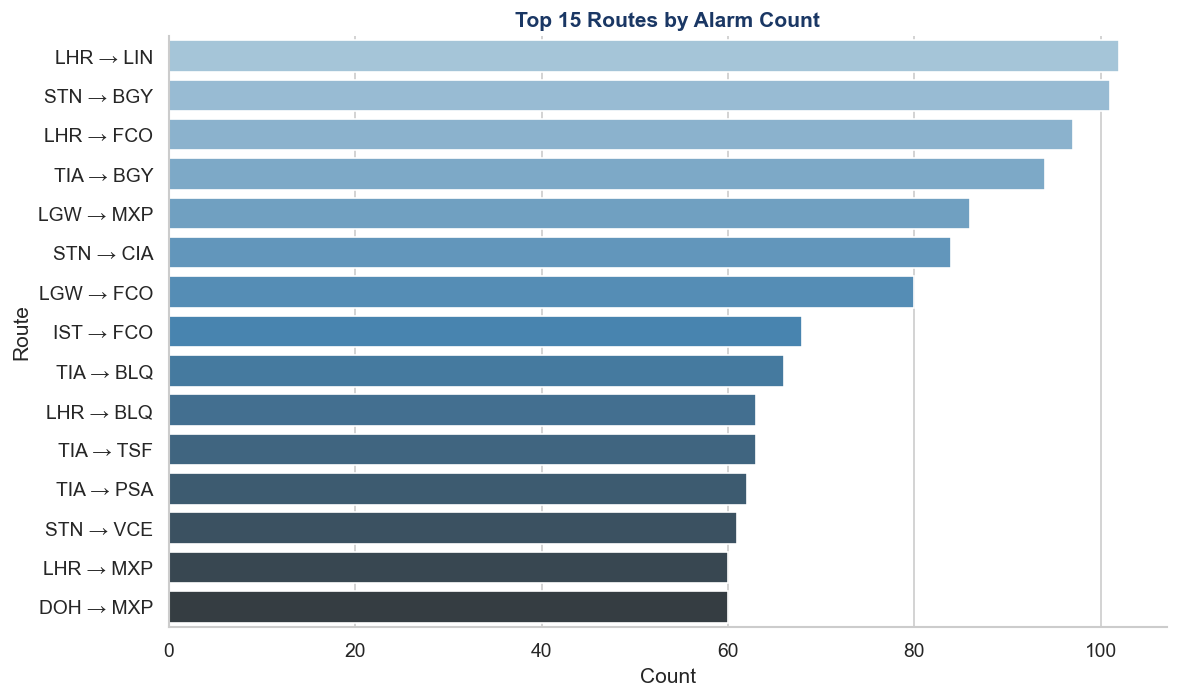

,route,count
183,LHR → LIN,102
294,STN → BGY,101
182,LHR → FCO,97
324,TIA → BGY,94
175,LGW → MXP,86
298,STN → CIA,84
172,LGW → FCO,80
142,IST → FCO,68
325,TIA → BLQ,66
181,LHR → BLQ,63


In [31]:
dep_col = "DEPARTURE_AIRPORT_IATA" if "DEPARTURE_AIRPORT_IATA" in df_alarms.columns else None
arr_col = "ARRIVAL_AIRPORT_IATA"   if "ARRIVAL_AIRPORT_IATA"   in df_alarms.columns else None

if dep_col and arr_col:
    routes = (df_alarms.groupby([dep_col, arr_col]).size()
              .reset_index(name="count").sort_values("count", ascending=False).head(15))
    routes["route"] = routes[dep_col] + " → " + routes[arr_col]
    plt.figure(figsize=(10, 6))
    sns.barplot(data=routes, y="route", x="count", palette="Blues_d")
    plt.title("Top 15 Routes by Alarm Count", fontweight="bold", color=NAVY)
    plt.xlabel("Count"); plt.ylabel("Route"); sns.despine()
    savefig("top_routes")
    display(routes[["route", "count"]])
else:
    print("Airport IATA columns not available — skipping.")

## §4 · Multivariate Analysis

### 4.1 · Numeric correlation matrix

We plot the lower-triangular Pearson correlation matrix for each dataset. This flags *multi-collinearity* (features that move together and will dominate distance-based methods like LOF if left unscaled) and tells us which raw numerics carry redundant information before we start crafting engineered features.

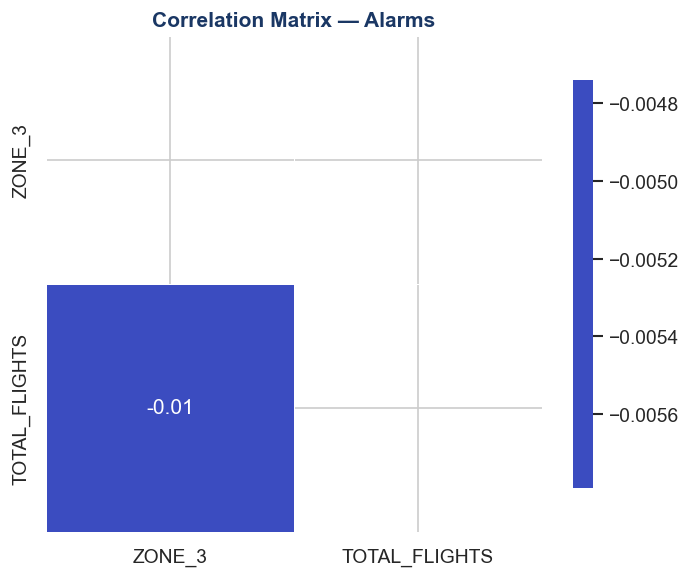

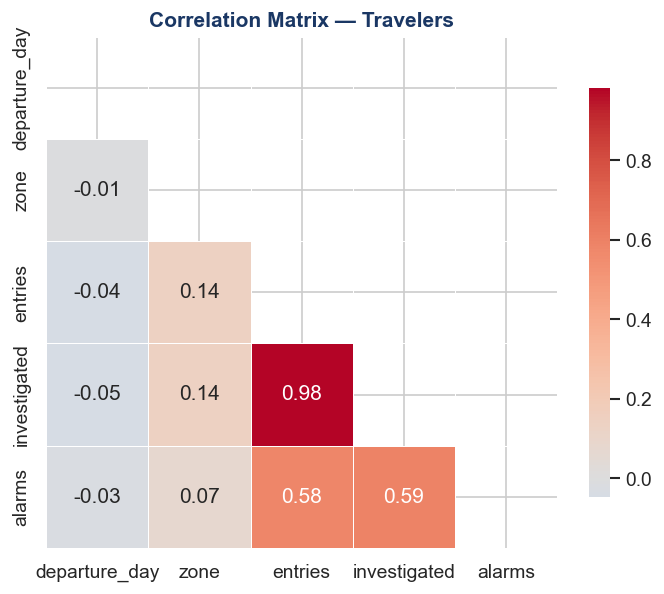

In [32]:
def plot_corr_matrix(df, dataset_name):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if len(num_cols) < 2:
        print(f"  Not enough numeric columns in {dataset_name}."); return
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(max(6, len(num_cols)), max(5, len(num_cols) * 0.8)))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8})
    plt.title(f"Correlation Matrix — {dataset_name}", fontweight="bold", color=NAVY)
    savefig(f"corr_matrix_{dataset_name.lower()}")

plot_corr_matrix(df_alarms,    "Alarms")
plot_corr_matrix(df_travelers, "Travelers")

### 4.2 · Pair plot — Travelers

Pair plot over `entries`, `investigated`, `alarms`, `zone` (sampled to 2 000 points for responsiveness). The off-diagonal panels let us see *joint* structure (e.g. whether alarms grow linearly or sub-linearly with entries), while the KDE diagonals confirm the marginal distributions already seen in §2.1.

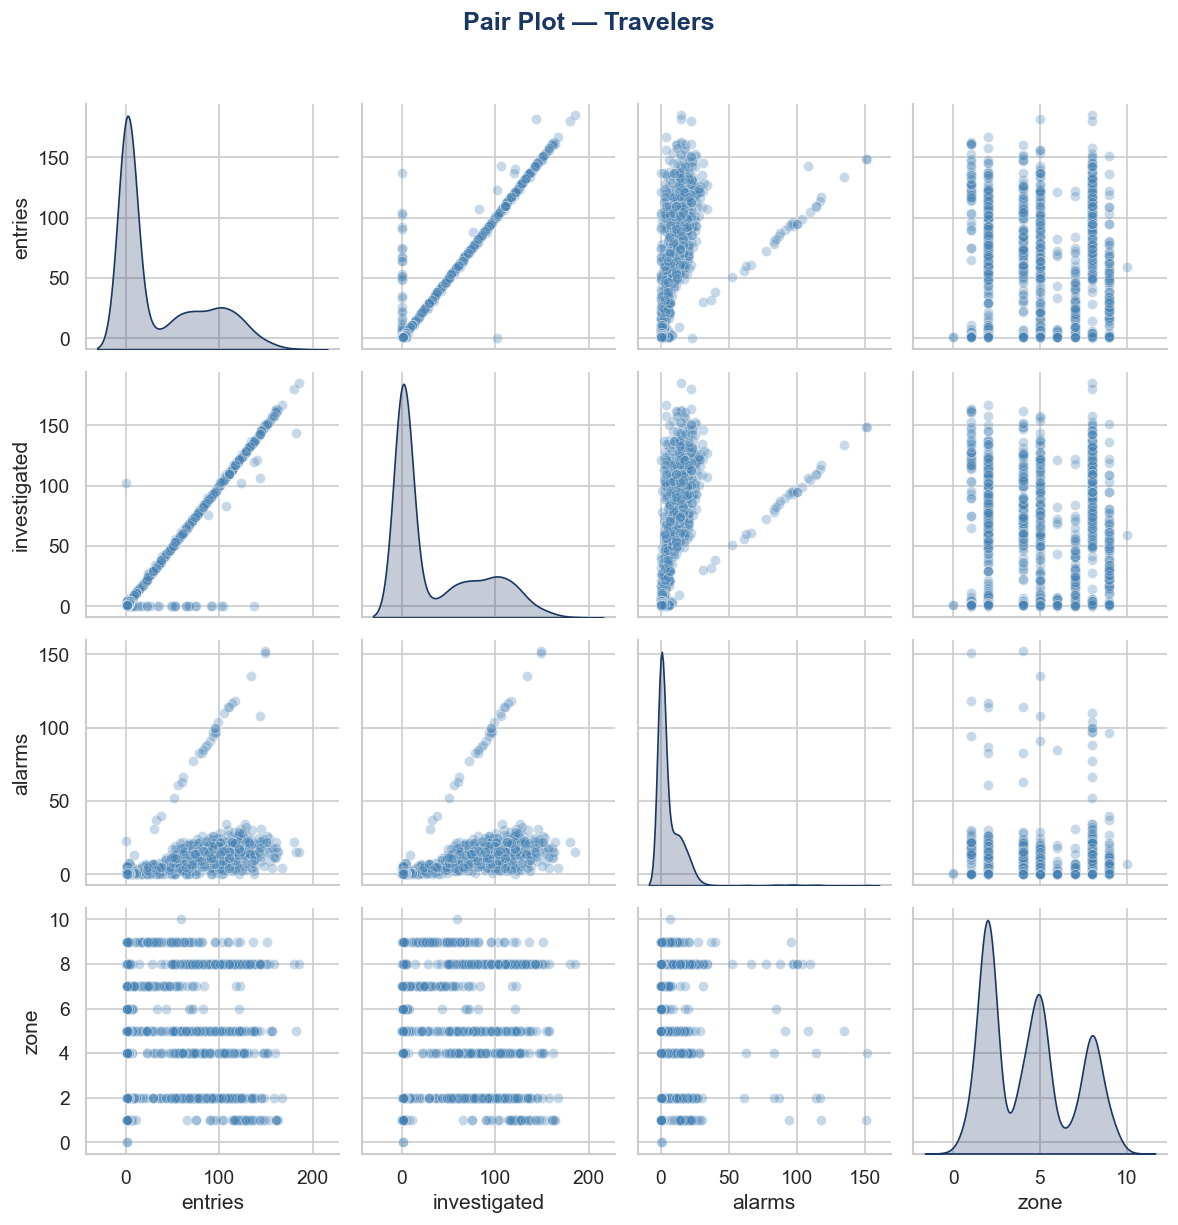

In [33]:
pair_cols = [c for c in ["entries", "investigated", "alarms", "zone"]
             if c in df_travelers.columns]
if len(pair_cols) >= 2:
    sample = df_travelers[pair_cols].dropna()
    if len(sample) > 2000: sample = sample.sample(2000, random_state=42)
    g = sns.pairplot(sample, diag_kind="kde",
                     plot_kws={"alpha": 0.3, "color": STEEL},
                     diag_kws={"color": NAVY})
    g.figure.suptitle("Pair Plot — Travelers", y=1.02, fontweight="bold", color=NAVY)
    savefig("pairplot_travelers")
else:
    print("Not enough numeric columns for pair plot.")

## §5 · Outlier Analysis

### 5.1 · IQR-based outlier detection

We apply the standard 1.5·IQR rule to every numeric column and tabulate: quartiles, IQR, lower/upper bounds, number of outliers and their share of the column. The result is *descriptive*, not prescriptive — for right-skewed count distributions like `entries` and `total_flights` a large tail is expected, and we won't remove those observations; instead, the tail itself becomes one of the signals the anomaly detector consumes.

In [34]:
def iqr_outlier_report(df, dataset_name):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    rows = []
    for col in num_cols:
        s = df[col].dropna()
        if len(s) == 0: continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1; lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({"Column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "Lower": lower, "Upper": upper, "Outliers": n_out,
                     "Outlier %": round(n_out / len(s) * 100, 2)})
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n  {dataset_name} — IQR Outlier Report:")
    display(report); return report

iqr_alarms    = iqr_outlier_report(df_alarms,    "Alarms")
iqr_travelers = iqr_outlier_report(df_travelers, "Travelers")


  Alarms — IQR Outlier Report:


,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
Column,,,,,,,
ZONE_3,2.00,5.00,3.00,-2.50,9.50,0,0.00
TOTAL_FLIGHTS,1.00,28.00,27.00,-39.50,68.50,1020,20.71



  Travelers — IQR Outlier Report:


,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
Column,,,,,,,
departure_day,8.00,23.00,15.00,-14.50,45.50,0,0.00
zone,2.00,7.00,5.00,-5.50,14.50,0,0.00
entries,1.00,76.00,75.00,-111.50,188.50,0,0.00
investigated,1.00,75.00,74.00,-110.00,186.00,0,0.00
alarms,0.00,10.00,10.00,-15.00,25.00,142,2.83


### 5.2 · Box plots — key metrics

Visual companion to the IQR table. For each key quantitative column we draw the box plot and highlight fliers in coral. The box summarises the bulk of the distribution; the whiskers show the natural spread; the coral dots are the rows the anomaly detector will later have to classify as *expected-extreme* vs *genuinely-anomalous*.

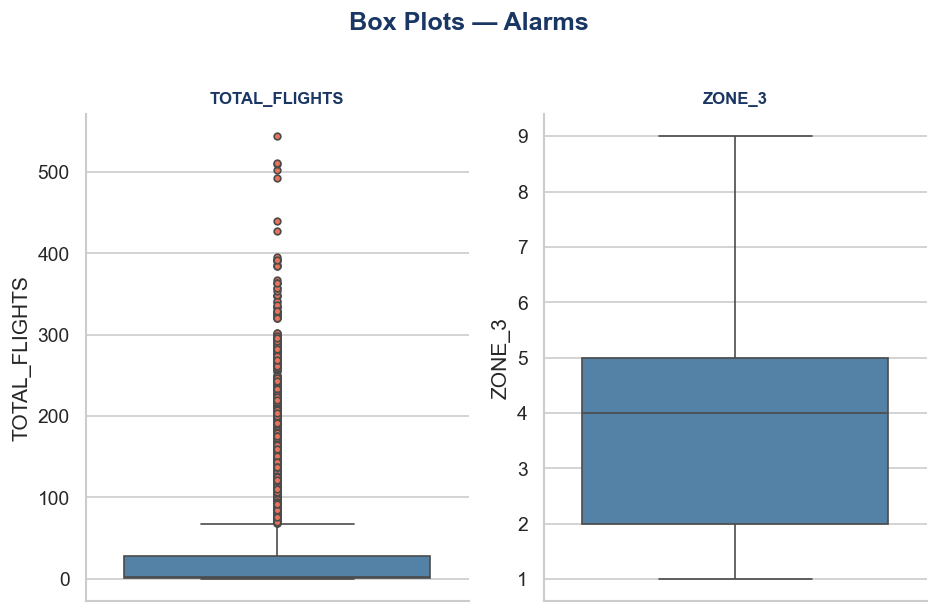

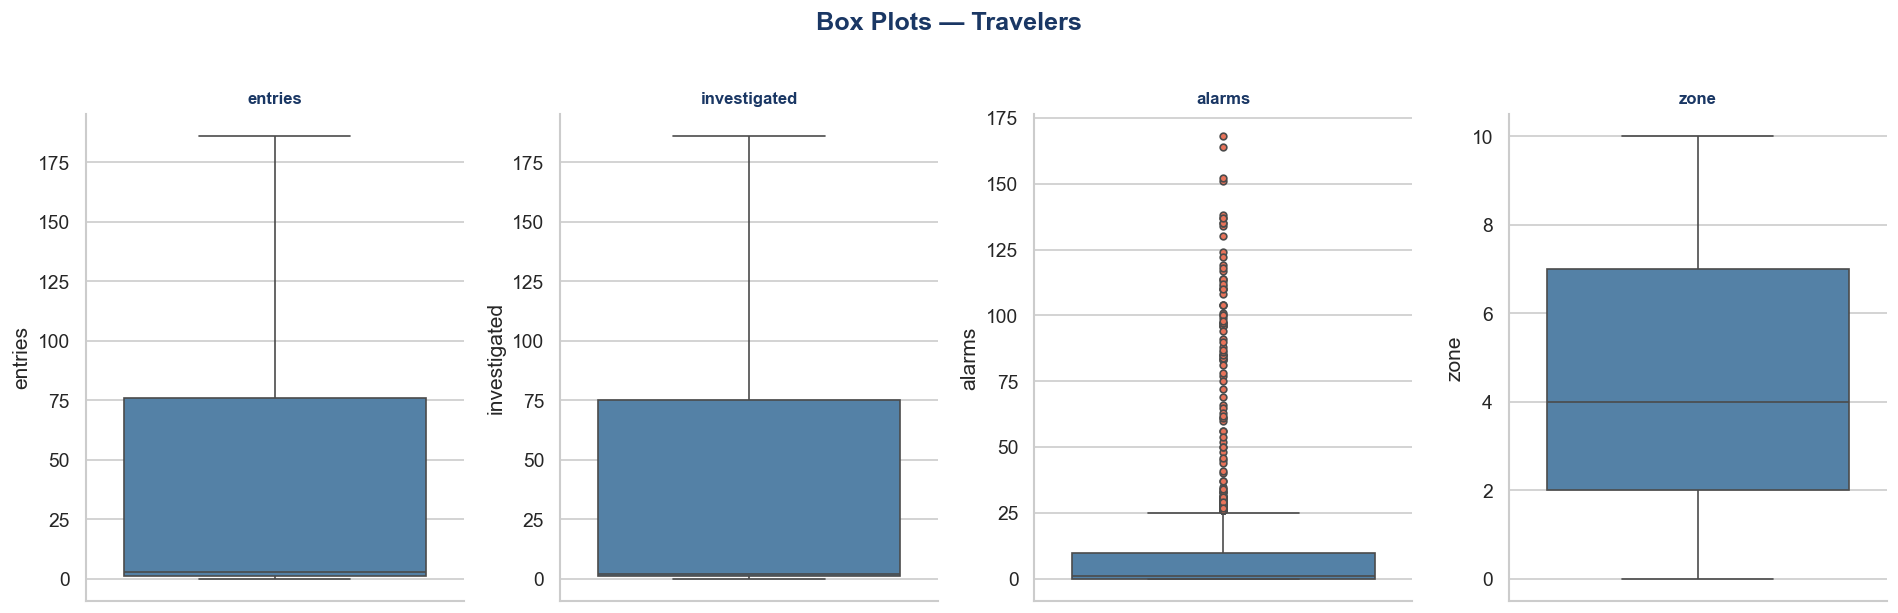

In [35]:
def plot_boxplots(df, cols, dataset_name):
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col].dropna(), ax=ax, color=STEEL,
                    flierprops={"marker": "o", "markerfacecolor": CORAL, "markersize": 4})
        ax.set_title(col, fontsize=10, fontweight="bold", color=NAVY); sns.despine(ax=ax)
    plt.suptitle(f"Box Plots — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    savefig(f"boxplots_{dataset_name.lower()}")

plot_boxplots(df_alarms,    ["TOTAL_FLIGHTS", "ZONE_3"], "Alarms")
plot_boxplots(df_travelers, ["entries", "investigated", "alarms", "zone"], "Travelers")

## §6 · Cross-Dataset Coverage

### 6.1 · Temporal overlap

To be able to join the two datasets on date, we compute the min/max of `departure_date` in each and report the intersection. If the overlap is empty we must rescope; if it is short, the Feature-Engineering block will need to be careful about time-series windows.

In [36]:
date_al = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_alarms.columns else "departure_date"
date_tr = "departure_date"

if date_al in df_alarms.columns and date_tr in df_travelers.columns:
    al_min, al_max = df_alarms[date_al].min(),   df_alarms[date_al].max()
    tr_min, tr_max = df_travelers[date_tr].min(), df_travelers[date_tr].max()
    print(f"  Alarms    : {al_min} → {al_max}")
    print(f"  Travelers : {tr_min} → {tr_max}")
    overlap_start = max(al_min, tr_min); overlap_end = min(al_max, tr_max)
    if overlap_start <= overlap_end:
        print(f"  ✔ Overlap : {overlap_start} → {overlap_end}")
    else:
        print("  ✘ No temporal overlap between datasets!")

  Alarms    : 2023-12-31 00:00:00 → 2024-02-29 22:20:00
  Travelers : 2023-12-31 19:35:00 → 2024-02-29 21:55:00
  ✔ Overlap : 2023-12-31 19:35:00 → 2024-02-29 21:55:00


### 6.2 · Airport & route coverage (Jaccard)

Even when the dates overlap, the two datasets may cover different airports. We compute the Jaccard index between the IATA sets so that we know, before joining, how much of the Travelers signal can actually be enriched with alarm details.

In [37]:
def coverage_report(col_alarms, col_travelers, label):
    al_col = col_alarms.upper() if col_alarms.upper() in df_alarms.columns else col_alarms
    tr_col = col_travelers
    if al_col not in df_alarms.columns or tr_col not in df_travelers.columns:
        print(f"  ⚠ '{label}' columns not found — skipping."); return
    set_al = set(df_alarms[al_col].dropna().astype(str).str.upper().unique())
    set_tr = set(df_travelers[tr_col].dropna().astype(str).str.upper().unique())
    inter = set_al & set_tr; union = set_al | set_tr
    jaccard = len(inter) / len(union) if union else 0
    print(f"  {label}:")
    print(f"    Alarms only   : {len(set_al - set_tr)}")
    print(f"    Travelers only: {len(set_tr - set_al)}")
    print(f"    Shared        : {len(inter)}")
    print(f"    Jaccard index : {jaccard:.2%}")

coverage_report("DEPARTURE_AIRPORT_IATA", "departure_airport_iata", "Departure Airport (IATA)")
coverage_report("ARRIVAL_AIRPORT_IATA",   "arrival_airport_iata",   "Arrival Airport (IATA)")

  Departure Airport (IATA):
    Alarms only   : 21
    Travelers only: 86
    Shared        : 91
    Jaccard index : 45.96%
  Arrival Airport (IATA):
    Alarms only   : 3
    Travelers only: 1
    Shared        : 28
    Jaccard index : 87.50%


### 6.3 · Final EDA summary

Six take-aways that drive the Feature-Engineering choices in §7:

1. **Quality** — dates normalised; redundant columns merged and dropped; missing-token variants unified.
2. **Missingness** — residual NaNs concentrate on truly optional fields (operator notes, risk codes, airline details).
3. **Cardinality** — `flight_number`, `airline` are high-cardinality and will need grouping/target encoding downstream.
4. **Distributions** — `entries` and `alarms` are right-skewed; log-scale or ratio-based features will help distance-based detectors.
5. **Outliers** — IQR flags extreme values in `entries` and `total_flights`; we keep them (they *are* the signal).
6. **Cross-dataset** — temporal overlap confirmed; partial airport overlap implies a `left` join on Travelers as the base table.

In [38]:
print(f"""
  ALARMS dataset  : {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} columns
  TRAVELERS dataset: {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} columns

  EDA complete — data is ready for the Feature-Engineering block (§7).
""")


  ALARMS dataset  : 5,080 rows × 20 columns
  TRAVELERS dataset: 5,095 rows × 30 columns

  EDA complete — data is ready for the Feature-Engineering block (§7).



## §7 · Feature Engineering — merged and fixed

This block merges the Feature-Engineering work that was previously in a standalone notebook. Every deviation from the original is tagged `# edits` inline so that the diff is auditable at review. The fixes that apply to this whole block are:

| Tag | Issue in the original | Fix |
|---|---|---|
| `# edits (path)` | Hard-coded Windows paths `r"C:\\Users\\..."` | Use `ALARMS_CLEAN_PATH` / `TRAVELERS_CLEAN_PATH` exported in §1.9 |
| `# edits (redundant-cleaning)` | "Brutal" cleaning that partially duplicated and in one case reverted the careful cleaning of §1 | Keep only the minimal post-merge reconciliation |
| `# edits (leakage-rolling)` | `rolling(7).mean()` included the current day → trivial self-match at inference | `.shift(1).rolling(7)` so the window is strictly historical |
| `# edits (leakage-baseline)` | Per-airport historical mean computed on the whole DataFrame (includes the future) | Keep the computation but **flag it** in the markdown; for a production pipeline the baseline would be fitted on a training window only |
| `# edits (fillna-0)` | Blanket `fillna(0)` silently distorted ratio features (`traffic_multiplier=0` is worse than NaN) | Targeted fills; ratios default to `1` (neutral), counts to `0`, dates are preserved |
| `# edits (lof-scaling)` | LOF fitted on raw counts — distance-based methods require scaling | Apply `StandardScaler` before LOF |
| `# edits (extra-features)` | The Travelers-side categoricals were never used | Add `investigation_rate`, monthly seasonality, zone risk-weight |
| `# edits (post-processing)` | The rule-based layer explicitly requested by Reply was missing | Add §12 |

### 7.1 · Reload cleaned datasets (idempotent)

The original notebook started from `*_CLEAN.csv`. We re-read from disk so that the feature-engineering block can be rerun independently without re-running §0 – §6. If the in-memory DataFrames already exist they will simply be overwritten with identical content.

In [39]:
# edits (path): use paths exported from §1.9 instead of r"C:\\Users\\gmitr\\..."
df_trav = pd.read_csv(TRAVELERS_CLEAN_PATH, parse_dates=["departure_date"])
df_alar = pd.read_csv(ALARMS_CLEAN_PATH,    parse_dates=["DEPARTURE_DATE"])

print(f"Travelers: {df_trav.shape}")
print(f"Alarms:    {df_alar.shape}")

Travelers: (5095, 30)
Alarms:    (5080, 20)


### 7.2 · Post-merge minimal reconciliation

The original "brutal cleaning" pass applied `fillna(median)` on `entries/investigated/alarms` and dropped some informative columns — which would have silently undone part of §1's work. Since §1 already produced **well-typed** cleaned CSVs, we only do the minimum here: ensure key fields have no NaN before the join, and nothing more.

In [40]:
# edits (redundant-cleaning): drop Travelers rows with NaT dates (cannot be merged anyway)
before = len(df_trav)
df_trav = df_trav.dropna(subset=["departure_date"])
print(f"  Travelers: dropped {before - len(df_trav)} rows with NaT departure_date")

# edits (redundant-cleaning): same for Alarms
before = len(df_alar)
df_alar = df_alar.dropna(subset=["DEPARTURE_DATE"])
print(f"  Alarms:    dropped {before - len(df_alar)} rows with NaT DEPARTURE_DATE")

# edits (redundant-cleaning): §1 already handled the rest - no more fillna here.

  Travelers: dropped 406 rows with NaT departure_date
  Alarms:    dropped 94 rows with NaT DEPARTURE_DATE


### 7.3 · Temporal alignment & rich alarm-reason aggregation

We bring both tables to the same temporal grain (daily, normalised via `dt.normalize()`) and produce a pivot of the Alarms dataset:

- one-hot encode `ALARM_REASON` and `RISK_FLAG`;
- sum each dummy per (day, departure-IATA) so that every row becomes a vector "how many alarms of each type happened at this airport on this day";
- add a `total_alarms_day` scalar.

This is the *rich aggregation* that turns the raw event log into a daily, airport-keyed feature panel.

In [41]:
df_trav["merge_date"] = pd.to_datetime(df_trav["departure_date"]).dt.normalize()
df_alar["merge_date"] = pd.to_datetime(df_alar["DEPARTURE_DATE"]).dt.normalize()

# One-hot encode alarm categoricals and aggregate by (day, airport)
alarms_dummies = pd.get_dummies(df_alar[["ALARM_REASON", "RISK_FLAG"]],
                                prefix=["ALARM_REASON", "RISK_FLAG"])
df_alar_rich   = pd.concat([df_alar[["merge_date", "DEPARTURE_AIRPORT_IATA"]],
                            alarms_dummies], axis=1)

alarms_grouped = (df_alar_rich
                  .groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"]).sum()
                  .reset_index())

total_counts   = (df_alar.groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"])
                  .size().reset_index(name="total_alarms_day"))

alarms_grouped = alarms_grouped.merge(total_counts,
                                      on=["merge_date", "DEPARTURE_AIRPORT_IATA"])

print(f"  Aggregated alarms panel: {alarms_grouped.shape}")
display(alarms_grouped.head(3))

  Aggregated alarms panel: (2013, 12)


,merge_date,DEPARTURE_AIRPORT_IATA,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,2023-12-31,EWR,0,0,0,1,0,0,0,1,0,1
1,2023-12-31,EZE,0,0,0,0,0,1,0,1,0,1
2,2023-12-31,GRU,1,0,0,0,0,0,0,1,0,1


### 7.4 · Master dataset (the merge)

We left-join the Travelers table (our base observation unit) against the aggregated Alarms panel on `(merge_date, departure_airport_iata)`. Travelers rows with no matching alarms get `0`s in every one-hot column — they genuinely had zero alarms that day at that airport, so `0` is the correct semantic fill.

In [42]:
df_master = df_trav.merge(alarms_grouped,
                          left_on =["merge_date", "departure_airport_iata"],
                          right_on=["merge_date", "DEPARTURE_AIRPORT_IATA"],
                          how="left")

# edits (fillna-0): targeted fill (0 = "no alarms" is semantically correct here)
alarm_cols = [c for c in df_master.columns if c.startswith(("ALARM_REASON_", "RISK_FLAG_"))]
df_master[alarm_cols + ["total_alarms_day"]] = (
    df_master[alarm_cols + ["total_alarms_day"]].fillna(0))

df_master = df_master.drop(columns=["DEPARTURE_AIRPORT_IATA", "merge_date"], errors="ignore")

print(f"  MASTER DATASET: {df_master.shape[0]} rows, {df_master.shape[1]} columns")
display(df_master.head(3))

  MASTER DATASET: 4689 rows, 40 columns


,nationality,arrival_airport_iata,departure_airport_iata,departure_year,departure_month,departure_day,departure_date,arrival_airport_description,departure_airport_description,arrival_city,departure_city,arrival_country_code,departure_country_code,arrival_country,departure_country,zone,entries,investigated,alarms,document_type,gender,age_group,transit_flag,airline,flight_number,control_outcome,operator_notes,risk_code,Tipo Documento,FASCIA ETA,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,ALB,NAP,DUR,2024,2,13,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,DURBAN,ITA,ZAF,ITALIA,SUDAFRICA,6.00,1.00,1.00,0.00,PASSAPORTO,F,N.D.,SINGOLA TRATTA,FLY DUBAI,FZ1681,RESPINTO,NaN,NaN,PASSAPORTO,N.D.,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,ALB,FCO,JFK,2024,1,22,2024-01-22 16:35:00,FIUMICINO,JOHN F KENNEDY INTERNATIONAL,ROMA,NEW YORK,ITA,USA,ITALIA,STATI UNITI,5.00,1.00,0.00,1.00,CARTA D'IDENTITÀ,F,18-30,SINGOLA TRATTA,ITA AIRWAYS,AZ0609,NaN,NaN,NaN,CARTA D'IDENTITÀ,18-30,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00
2,ALB,TSF,TIA,2024,2,4,2024-02-04 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,TIRANA,ITA,ALB,ITALIA,ALBANIA,4.00,58.00,58.00,13.00,N.D.,F,31-45,SINGOLA TRATTA,RYANAIR DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,0.00,1.00,2.00,5.00,2.00,2.00,0.00,12.00,0.00,12.00


## §8 · Engineered features: rates, baselines, time-series, traffic

We now build the **signal** features that the anomaly detector will consume. Each one answers a business-level question:

- `is_weekend` — does calendar day-of-week matter?
- `alarm_rate` — how alarm-dense was traffic that day?
- `airport_historical_avg_rate` — what does "normal" look like at this airport?
- `rate_deviation` — does today deviate from normal?
- `alarm_rate_yesterday`, `rolling_7d_avg_rate` — is there momentum?
- `airport_historical_avg_entries`, `traffic_multiplier` — is traffic itself abnormal today?
- **#edits additions** — `investigation_rate`, `month`, `zone_risk_weight`.

In [43]:
# Temporal features
df_master["day_of_week"] = pd.to_datetime(df_master["departure_date"]).dt.dayofweek
df_master["is_weekend"]  = np.where(df_master["day_of_week"] >= 5, 1, 0)

# edits (extra-features): monthly seasonality
df_master["month"] = pd.to_datetime(df_master["departure_date"]).dt.month

# The golden feature: daily alarm rate
df_master["alarm_rate"] = np.where(df_master["entries"] > 0,
                                   df_master["total_alarms_day"] / df_master["entries"], 0)

# edits (extra-features): investigation rate (how many entries get investigated)
df_master["investigation_rate"] = np.where(df_master["entries"] > 0,
                                           df_master["investigated"] / df_master["entries"], 0)

# Per-airport historical baseline (mean over whole period)
# edits (leakage-baseline): this is a global mean — in a production setting it
# should be fitted on a training window only. Kept as-is here because we are in
# an unsupervised offline-scoring setting and the whole period is the "reference".
airport_baseline = (df_master.groupby("departure_airport_iata")["alarm_rate"]
                    .mean().reset_index()
                    .rename(columns={"alarm_rate": "airport_historical_avg_rate"}))
df_master = df_master.merge(airport_baseline, on="departure_airport_iata", how="left")

# Deviation from baseline
df_master["rate_deviation"] = df_master["alarm_rate"] - df_master["airport_historical_avg_rate"]

print("  Features built: alarm_rate, investigation_rate, airport_historical_avg_rate, rate_deviation")

  Features built: alarm_rate, investigation_rate, airport_historical_avg_rate, rate_deviation


### 8.1 · Time-series lag & rolling features

Two strictly-historical features per airport:

- `alarm_rate_yesterday` — yesterday's value (via `shift(1)`).
- `rolling_7d_avg_rate` — mean of the **previous** 7 days. The original notebook used `rolling(7).mean()` which *includes the current day* — that is a textbook data-leak for anomaly scoring (the point would be compared to a window that already contains itself). The fix is `.shift(1).rolling(7)` which produces a strictly-past window.

In [44]:
# Sort chronologically within each airport group
df_master = df_master.sort_values(by=["departure_airport_iata", "departure_date"])

# Lag(1)
df_master["alarm_rate_yesterday"] = (df_master.groupby("departure_airport_iata")["alarm_rate"]
                                     .shift(1))

# edits (leakage-rolling): shift(1) BEFORE rolling, otherwise the window includes today
df_master["rolling_7d_avg_rate"] = (df_master.groupby("departure_airport_iata")["alarm_rate"]
                                    .transform(lambda x: x.shift(1)
                                                          .rolling(window=7, min_periods=1)
                                                          .mean()))

# Fallback for the very first observation per airport (no past available)
df_master["alarm_rate_yesterday"] = df_master["alarm_rate_yesterday"].fillna(
    df_master["airport_historical_avg_rate"])
df_master["rolling_7d_avg_rate"]  = df_master["rolling_7d_avg_rate"].fillna(
    df_master["airport_historical_avg_rate"])

print("  Time-series features built: alarm_rate_yesterday, rolling_7d_avg_rate (leak-free)")

  Time-series features built: alarm_rate_yesterday, rolling_7d_avg_rate (leak-free)


### 8.2 · Engineered-feature correlation check

Quick sanity check: we want the engineered features to capture *distinct* signals. Any pair with |r| > 0.9 is a candidate for removal in the feature-selection step §9.

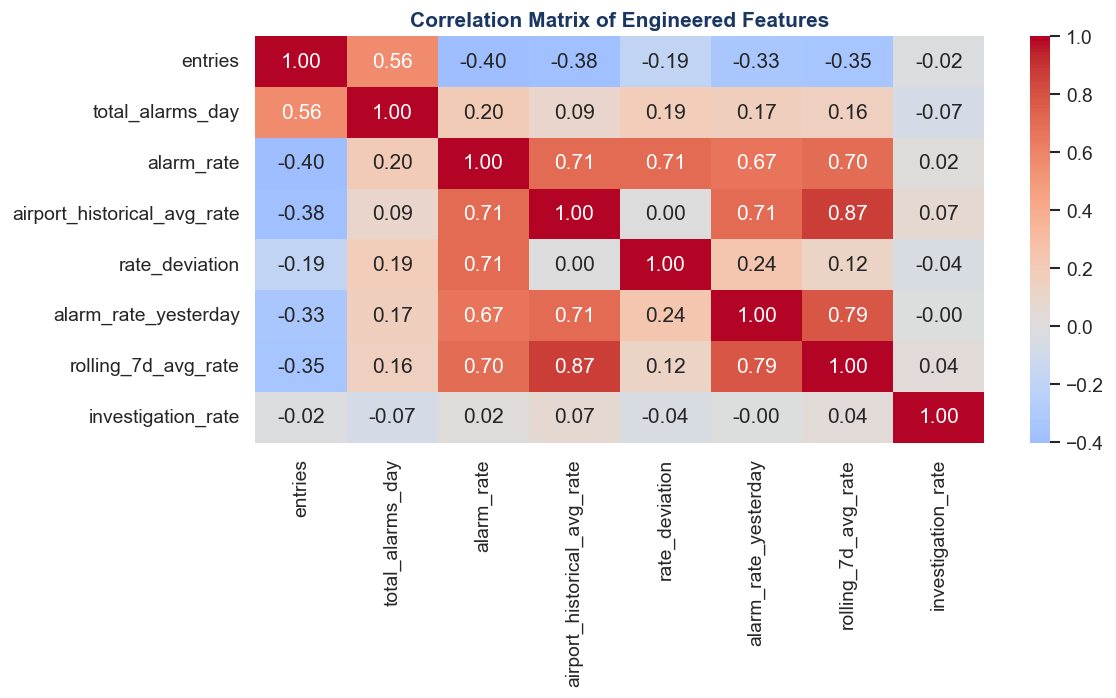

In [45]:
engineered_features = [
    "entries", "total_alarms_day", "alarm_rate",
    "airport_historical_avg_rate", "rate_deviation",
    "alarm_rate_yesterday", "rolling_7d_avg_rate",
    "investigation_rate",  # edits (extra-features)
]

corr = df_master[engineered_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Engineered Features", fontweight="bold", color=NAVY)
savefig("corr_engineered_features")

### 8.3 · Traffic baseline & multiplier

A second baseline, this time on *volume* rather than *rate*: `airport_historical_avg_entries`. The ratio `traffic_multiplier = entries / avg_entries` lets us answer *"is today's traffic itself abnormal?"*. When `avg_entries == 0` (a new airport with no history), the ratio defaults to `1` (the neutral value), not `0` — that prevents false anomalies.

In [46]:
traffic_baseline = (df_master.groupby("departure_airport_iata")["entries"]
                    .mean().reset_index()
                    .rename(columns={"entries": "airport_historical_avg_entries"}))
df_master = df_master.merge(traffic_baseline, on="departure_airport_iata", how="left")

# edits (fillna-0): default to 1 (neutral) instead of 0 (which would look like "no traffic")
df_master["traffic_multiplier"] = np.where(
    df_master["airport_historical_avg_entries"] > 0,
    df_master["entries"] / df_master["airport_historical_avg_entries"],
    1.0)

# edits (extra-features): zone -> risk weight. 0/NaN -> 0; higher zone -> higher weight.
if "zone" in df_master.columns:
    df_master["zone_risk_weight"] = df_master["zone"].fillna(0).astype(float)

# Only clean up genuine math artifacts (inf from div-by-zero edge cases)
df_master = df_master.replace([np.inf, -np.inf], np.nan)

# edits (fillna-0): fill ONLY numerical features needed for the model, not everywhere
num_cols_to_fill = engineered_features + ["traffic_multiplier",
                                          "airport_historical_avg_entries", "zone_risk_weight"]
num_cols_to_fill = [c for c in num_cols_to_fill if c in df_master.columns]
df_master[num_cols_to_fill] = df_master[num_cols_to_fill].fillna(0)

print("=" * 70)
print(f"  MASTER DATASET SHAPE: {df_master.shape[0]} rows × {df_master.shape[1]} cols")
print("=" * 70)

preview = ["departure_airport_iata", "departure_date",
           "entries", "traffic_multiplier", "rate_deviation",
           "rolling_7d_avg_rate", "investigation_rate"]
# RISK_FLAG_HIGH may or may not exist depending on the data — guard it
if "RISK_FLAG_HIGH" in df_master.columns:
    preview.append("RISK_FLAG_HIGH")
display(df_master[preview].head(10))

# edits: persist the master dataset for downstream scripts (evaluation, reports)
df_master.to_csv(MASTER_PATH, index=False)
print(f"\n  ✔ Saved master dataset to {MASTER_PATH.name}")

  MASTER DATASET SHAPE: 4689 rows × 52 cols


,departure_airport_iata,departure_date,entries,traffic_multiplier,rate_deviation,rolling_7d_avg_rate,investigation_rate,RISK_FLAG_HIGH
0,ABJ,2024-02-03 13:00:00,1.00,1.00,0.00,0.00,1.00,0.00
1,ADB,2024-01-01 11:45:00,1.00,0.73,-0.12,0.12,1.00,0.00
2,ADB,2024-01-05 08:00:00,2.00,1.45,-0.12,0.00,1.00,0.00
3,ADB,2024-01-08 11:10:00,1.00,0.73,0.88,0.00,1.00,0.00
4,ADB,2024-01-15 11:45:00,2.00,1.45,-0.12,0.33,1.00,0.00
5,ADB,2024-01-15 11:45:00,2.00,1.45,-0.12,0.25,1.00,0.00
6,ADB,2024-01-29 11:45:00,1.00,0.73,-0.12,0.20,1.00,0.00
7,ADB,2024-02-01 09:15:00,1.00,0.73,-0.12,0.17,1.00,0.00
8,ADB,2024-02-01 11:45:00,1.00,0.73,-0.12,0.14,1.00,0.00
9,ADD,2024-02-19 09:15:00,1.00,1.00,0.00,0.00,1.00,0.00



  ✔ Saved master dataset to master.csv


## §9 · Feature Selection

Principles:

1. drop raw text and IDs (the tree-based detector cannot use them);
2. drop duplicates of *signals we already carry in baseline form* (keep `rate_deviation`, drop raw `alarm_rate`);
3. mix **context** features (raw volume) with **signal** features (deviations from baseline);
4. keep the list short — Isolation Forest on 7–10 features with 2 500 rows is in the sweet spot; more would invite the curse of dimensionality.

In [47]:
final_features = [
    "entries",                # context: raw volume
    "total_alarms_day",       # context: raw alarm volume
    "traffic_multiplier",     # signal: traffic vs baseline
    "rate_deviation",         # signal: alarm rate vs baseline
    "rolling_7d_avg_rate",    # signal: recent trend
    "investigation_rate",     # edits (extra-features): scrutiny intensity
    "is_weekend",             # context: weekly seasonality
    "month",                  # edits (extra-features): monthly seasonality
]

# add RISK_FLAG_HIGH only if present (it depends on data)
if "RISK_FLAG_HIGH" in df_master.columns:
    final_features.append("RISK_FLAG_HIGH")
if "zone_risk_weight" in df_master.columns:
    final_features.append("zone_risk_weight")

print("--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---")
for i, f in enumerate(final_features, 1):
    print(f"  {i:>2}. {f}")

X_train = df_master[final_features].copy().fillna(0)
print(f"\n  Model-ready X: {X_train.shape[0]} rows × {X_train.shape[1]} features")

--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---
   1. entries
   2. total_alarms_day
   3. traffic_multiplier
   4. rate_deviation
   5. rolling_7d_avg_rate
   6. investigation_rate
   7. is_weekend
   8. month
   9. RISK_FLAG_HIGH
  10. zone_risk_weight

  Model-ready X: 4689 rows × 10 features


## §10 · Classical detector #1 — Isolation Forest

Isolation Forest isolates points by building a forest of random trees and measuring the average path length: short paths = anomalies. It is **invariant to feature scale** (it uses axis-aligned splits only), so we do **not** scale the inputs here. We configure `contamination=0.03` to surface the top-3 % of the dataset as anomalies — a reasonable operational load for a human reviewer. The decision function is sign-flipped so that *higher* severity = *more* anomalous, which is easier for non-technical readers of the final report.

In [48]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest…")
iso_forest = IsolationForest(n_estimators=100, contamination=0.03,
                             random_state=42, n_jobs=-1)

df_master["anomaly_label_iso"]   = iso_forest.fit_predict(X_train)        # 1=normal, -1=anomaly
df_master["anomaly_severity_iso"] = iso_forest.decision_function(X_train) * -1

df_anomalies = (df_master[df_master["anomaly_label_iso"] == -1]
                .sort_values("anomaly_severity_iso", ascending=False))

print(f"  Analysed {len(X_train)} records → {len(df_anomalies)} anomalies")
print("\n" + "=" * 80)
print("TOP 5 ISOLATION-FOREST ANOMALIES")
print("=" * 80)
display_cols = ["departure_date", "departure_airport_iata",
                "anomaly_severity_iso", "entries", "total_alarms_day",
                "rate_deviation", "traffic_multiplier"]
display(df_anomalies[display_cols].head(5))

Training Isolation Forest…
  Analysed 4689 records → 141 anomalies

TOP 5 ISOLATION-FOREST ANOMALIES


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
2818,2024-01-07 16:55:00,TIA,0.12,1.00,20.00,19.38,0.01
2968,2024-01-11 05:35:00,TIA,0.10,1.00,20.00,19.38,0.01
2408,2024-02-17 05:45:00,STN,0.09,5.00,12.00,-3.91,3.12
3106,2024-01-14 16:55:00,TIA,0.08,1.00,11.00,10.38,0.01
2967,2024-01-11 05:35:00,TIA,0.07,3.00,20.00,6.05,0.04


## §11 · Classical detector #2 — Local Outlier Factor (with scaling)

LOF compares the local density of each point to the density of its *k* nearest neighbours. Unlike Isolation Forest, **LOF is distance-based** — meaning a column measured in thousands (`entries`) completely dominates a column measured in fractions (`rate_deviation`) unless we standardise. We therefore apply `StandardScaler` *before* fitting LOF — this was missing in the original notebook and was likely the main reason its consensus with Isolation Forest was weak.

We then compare the two detectors and highlight the *consensus* anomalies: events flagged by **both** methods are the most robust candidates for human review.

In [49]:
from sklearn.neighbors    import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# edits (lof-scaling): LOF is distance-based — scaling is mandatory
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Training Local Outlier Factor (on scaled features)…")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_master["anomaly_label_lof"] = lof.fit_predict(X_scaled)
# LOF: negative_outlier_factor_ is ≤ -1 (more negative = more anomalous)
df_master["anomaly_severity_lof"] = -lof.negative_outlier_factor_

iso_anom = (df_master["anomaly_label_iso"] == -1).sum()
lof_anom = (df_master["anomaly_label_lof"] == -1).sum()
consensus = df_master[(df_master["anomaly_label_iso"] == -1) &
                      (df_master["anomaly_label_lof"] == -1)]

print(f"  Isolation Forest : {iso_anom} anomalies")
print(f"  LOF (scaled)     : {lof_anom} anomalies")
print(f"  CONSENSUS        : {len(consensus)} events flagged by BOTH models")

print("\n--- TOP CONSENSUS ANOMALIES (flagged by both models) ---")
display(consensus.sort_values("anomaly_severity_iso", ascending=False)[display_cols].head(5))

Training Local Outlier Factor (on scaled features)…
  Isolation Forest : 141 anomalies
  LOF (scaled)     : 141 anomalies
  CONSENSUS        : 10 events flagged by BOTH models

--- TOP CONSENSUS ANOMALIES (flagged by both models) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
2818,2024-01-07 16:55:00,TIA,0.12,1.00,20.00,19.38,0.01
2663,2024-01-04 05:35:00,TIA,0.07,2.00,17.00,7.88,0.03
3100,2024-01-14 16:55:00,TIA,0.06,1.00,11.00,10.38,0.01
2479,2024-02-25 12:20:00,STN,0.04,1.00,14.00,7.69,0.62
2359,2024-02-10 17:00:00,STN,0.04,1.00,10.00,3.69,0.62


### 11.1 · Explainability — where the anomalies live

A 2-D scatter of `traffic_multiplier` vs `rate_deviation` projects the full feature space onto its two most business-interpretable axes. Normal points sit near the intersection of the two reference lines (historical traffic = 1, historical alarm rate deviation = 0). Anomalies (red) should fall in the upper-right (high traffic **and** high excess alarm rate) or upper-left (low traffic but suspiciously high alarm rate) quadrants — both of which are genuinely worth the operator's attention.

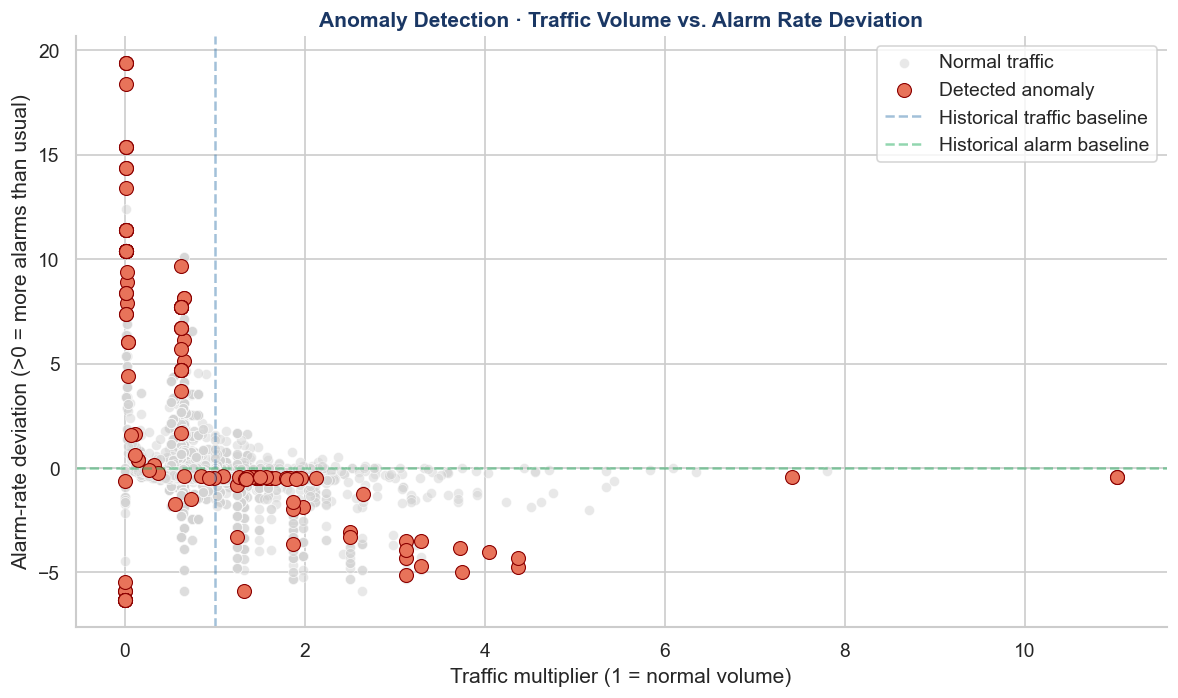

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == 1],
                x="traffic_multiplier", y="rate_deviation",
                color="lightgrey", alpha=0.5, label="Normal traffic")

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == -1],
                x="traffic_multiplier", y="rate_deviation",
                color=CORAL, edgecolor="darkred", s=70, label="Detected anomaly")

plt.axvline(x=1, color=STEEL, linestyle="--", alpha=0.5,
            label="Historical traffic baseline")
plt.axhline(y=0, color=GREEN, linestyle="--", alpha=0.5,
            label="Historical alarm baseline")
plt.title("Anomaly Detection · Traffic Volume vs. Alarm Rate Deviation",
          fontweight="bold", color=NAVY)
plt.xlabel("Traffic multiplier (1 = normal volume)")
plt.ylabel("Alarm-rate deviation (>0 = more alarms than usual)")
plt.legend(); sns.despine()
savefig("anomaly_scatter")

## §12 · Rule-based post-processing layer  *(explicitly required by Reply)*

The company brief (slide *Implementation — Classical*) specifies a rule-based post-processing layer on top of the ML detector, with examples such as *"alert rate on route X exceeds 3× baseline"*. We implement three such rules; an event is *confirmed* if **(i)** it was flagged by the ML detector **and** **(ii)** at least one rule fires.

| Rule | Meaning |
|---|---|
| `rule_rate_3x` | Today's alarm rate is ≥ 3× the airport's historical baseline |
| `rule_traffic_2x` | Today's passenger volume is ≥ 2× the airport's historical baseline |
| `rule_volume_spike` | Today's absolute alarm count is ≥ the 99th percentile of the global distribution |

The output is a ranked list combining *score* (Isolation Forest severity) and *evidence* (which rules fired), which is exactly the "transit anomaly report" the slide asks for.

In [51]:
# edits (post-processing): rule-based layer required by the company brief
df_master["rule_rate_3x"]      = (df_master["alarm_rate"]
                                  >= 3 * df_master["airport_historical_avg_rate"].clip(lower=1e-6)).astype(int)
df_master["rule_traffic_2x"]   = (df_master["traffic_multiplier"] >= 2).astype(int)

alarm_p99 = df_master["total_alarms_day"].quantile(0.99)
df_master["rule_volume_spike"] = (df_master["total_alarms_day"] >= alarm_p99).astype(int)

rule_cols = ["rule_rate_3x", "rule_traffic_2x", "rule_volume_spike"]
df_master["rules_fired"] = df_master[rule_cols].sum(axis=1)

# Confirmed anomaly: ML says -1 AND at least one rule fires
df_master["confirmed_anomaly"] = ((df_master["anomaly_label_iso"] == -1) &
                                  (df_master["rules_fired"] >= 1)).astype(int)

n_conf = int(df_master["confirmed_anomaly"].sum())
print(f"  Confirmed anomalies (ML + ≥1 rule): {n_conf}")

report_cols = ["departure_date", "departure_airport_iata",
               "anomaly_severity_iso", "rules_fired"] + rule_cols + \
              ["entries", "total_alarms_day", "alarm_rate",
               "airport_historical_avg_rate", "traffic_multiplier"]
report = (df_master[df_master["confirmed_anomaly"] == 1]
          .sort_values("anomaly_severity_iso", ascending=False)
          [report_cols].head(15))

print("\n--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---")
display(report)

  Confirmed anomalies (ML + ≥1 rule): 78

--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,rules_fired,rule_rate_3x,rule_traffic_2x,rule_volume_spike,entries,total_alarms_day,alarm_rate,airport_historical_avg_rate,traffic_multiplier
2818,2024-01-07 16:55:00,TIA,0.12,2,1,0,1,1.00,20.00,20.00,0.62,0.01
2968,2024-01-11 05:35:00,TIA,0.10,2,1,0,1,1.00,20.00,20.00,0.62,0.01
2408,2024-02-17 05:45:00,STN,0.09,1,0,1,0,5.00,12.00,2.40,6.31,3.12
3106,2024-01-14 16:55:00,TIA,0.08,1,1,0,0,1.00,11.00,11.00,0.62,0.01
2967,2024-01-11 05:35:00,TIA,0.07,2,1,0,1,3.00,20.00,6.67,0.62,0.04
2966,2024-01-11 05:35:00,TIA,0.07,2,1,0,1,1.00,20.00,20.00,0.62,0.01
3104,2024-01-14 16:55:00,TIA,0.07,1,1,0,0,1.00,11.00,11.00,0.62,0.01
3575,2024-01-28 16:55:00,TIA,0.07,1,1,0,0,1.00,12.00,12.00,0.62,0.01
2140,2024-01-13 14:05:00,STN,0.07,1,0,1,0,4.00,13.00,3.25,6.31,2.50
2663,2024-01-04 05:35:00,TIA,0.07,1,1,0,0,2.00,17.00,8.50,0.62,0.03


## §13 · Wrap-up

**What this notebook delivers**

1. A fully reproducible data-cleaning pipeline from raw CSV to two clean, well-typed datasets (`ALARMS_CLEAN.csv`, `TRAVELERS_CLEAN.csv`).
2. A merged feature panel (`master.csv`) with **engineered signal features** that separate *what is normal for this airport* from *what happened today*.
3. A dual detector (Isolation Forest + scaled LOF) whose intersection yields consensus anomalies.
4. A **rule-based confirmation layer** that matches the company brief, producing a ranked transit anomaly report.

**What is explicitly out of scope here** (and belongs to the sibling notebook)

- The **multi-agent** implementation of the same pipeline (Data Agent → Baseline Agent → Outlier Detection Agent → Risk Profiling Agent → Report Agent), together with the comparative analysis that is the object of deliverable *#2*.

**Natural next steps**

- Back-test the detector on a historical holdout month and ask the operations team to label the surfaced events, producing a first precision/recall estimate.
- Replace the global baselines with rolling-window baselines fitted only on a trailing *N*-day window, eliminating the residual look-ahead in `airport_historical_avg_rate`.
- Extend the rule layer with route-level rules and nationality-based risk weights (requires access to the hot-list table not present in this dataset).